# [품질] 데이터 전처리 방법에 따른 결과 분석
## 결측치 처리 방법 비교 및 모델 성능 평가

| 별칭 | 데이터셋 | 특징 |
|------|---------|------|
| 1,000단위 | Titanic | ~891 rows, Age 20% 결측 |
| 고결측(중소) | Pima Indians | ~768 rows, Insulin 49% / SkinThickness 30% 결측 |
| 10,000단위 | Telco Churn | ~7,043 rows, TotalCharges 소수 결측 |
| 이상치 다수 | Credit Card Fraud | ~284,807 rows, 결측 없음 / 극단적 클래스 불균형 |

### 분석 흐름
1. **결측치 처리 방법별 분포 변화 & Wall Time** — Median / RF / MICE
2. **LightGBM 평가** — 처리 방법별 성능 비교
3. **RandomForest & LogisticRegression 평가** — 모델 간 비교
4. **LightGBM 하이퍼파라미터 튜닝** — Default / GridSearch / Optuna

In [15]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from lightgbm import LGBMClassifier
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.float_format', '{:.4f}'.format)
print('라이브러리 로드 완료')

라이브러리 로드 완료


In [16]:
BASE = 'data/26_03_29_data'
PATHS = {
    'titanic': f'{BASE}/Titanic_Machine_Learning_from_Disaster/train.csv',
    'pima':    f'{BASE}/Pima_indians/diabetes.csv',
    'telco':   f'{BASE}/Telco_Customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv',
    'credit':  f'{BASE}/Credit_card_Fraud_Detection/creditcard.csv',
}
ALIASES = {
    'titanic': '1,000단위\n(Titanic)',
    'pima':    '고결측(중소)\n(Pima)',
    'telco':   '10,000단위\n(Telco)',
    'credit':  '이상치다수\n(Credit)',
}
DATASET_KEYS = ['titanic', 'pima', 'telco', 'credit']
IMP_COLORS   = {'Median': '#4C72B0', 'RF': '#55A868', 'MICE': '#C44E52'}
IMP_ORDER    = ['Median', 'RF', 'MICE']

In [17]:
PIMA_ZERO_COLS = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

def load_titanic(p):
    df = pd.read_csv(p)
    df = df.drop(columns=['PassengerId','Name','Ticket','Cabin'])
    df['Sex'] = (df['Sex']=='female').astype(int)
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
    df = df.astype({c:int for c in df.select_dtypes('bool').columns})
    return df.drop(columns=['Survived']).astype(float), df['Survived']

def load_pima(p):
    df = pd.read_csv(p)
    df[PIMA_ZERO_COLS] = df[PIMA_ZERO_COLS].replace(0, np.nan)
    return df.drop(columns=['Outcome']).astype(float), df['Outcome']

def load_telco(p):
    df = pd.read_csv(p).drop(columns=['customerID'])
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['Churn'] = (df['Churn']=='Yes').astype(int)
    df = pd.get_dummies(df, columns=df.select_dtypes('object').columns.tolist(), drop_first=True)
    df = df.astype({c:int for c in df.select_dtypes('bool').columns})
    return df.drop(columns=['Churn']).astype(float), df['Churn']

def load_credit(p):
    df = pd.read_csv(p)
    return df.drop(columns=['Class']).astype(float), df['Class']

In [18]:
loaders = {'titanic':load_titanic,'pima':load_pima,'telco':load_telco,'credit':load_credit}
datasets = {k: loaders[k](PATHS[k]) for k in DATASET_KEYS}

for k,(X,y) in datasets.items():
    miss = X.isnull().sum().sum()
    alias = ALIASES[k].replace('\n',' ')
    print(f'{alias:<22} shape={X.shape}  missing={miss}  target={y.value_counts().to_dict()}')

1,000단위 (Titanic)      shape=(891, 8)  missing=177  target={0: 549, 1: 342}
고결측(중소) (Pima)         shape=(768, 8)  missing=652  target={0: 500, 1: 268}
10,000단위 (Telco)       shape=(7043, 30)  missing=11  target={0: 5174, 1: 1869}
이상치다수 (Credit)         shape=(284807, 30)  missing=0  target={0: 284315, 1: 492}


---
## 섹션 1. 결측치 처리 방법별 분포 변화 & Wall Time

각 데이터셋에 Median / RF / MICE 를 적용하고
- **(a) 소요 시간(Wall Time)** 과
- **(b) 결측치가 채워진 방식의 분포 변화** 를 비교합니다.

> 이후 섹션의 모델 평가에서는 여기서 계산된 대치 결과를 **재사용**합니다.

In [19]:
def get_imputers():
    return {
        'Median': SimpleImputer(strategy='median'),
        'RF':     IterativeImputer(
                      estimator=RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1),
                      random_state=42, max_iter=5),
        'MICE':   IterativeImputer(
                      estimator=BayesianRidge(),
                      random_state=42, max_iter=10),
    }

In [20]:
%%time
splits  = {}   # {ds_key: (X_tr_raw, X_te_raw, y_tr, y_te)}
imputed = {}   # {(ds_key, imp): (X_tr_np, X_te_np)}
timing  = []

for ds_key in DATASET_KEYS:
    X, y = datasets[ds_key]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    splits[ds_key] = (X_tr, X_te, y_tr, y_te)
    alias = ALIASES[ds_key].replace('\n',' ')

    for imp_name, imp_tmpl in get_imputers().items():
        imp = clone(imp_tmpl)
        t0 = time()
        X_tr_imp = imp.fit_transform(X_tr)
        X_te_imp = imp.transform(X_te)
        elapsed  = time() - t0
        imputed[(ds_key, imp_name)] = (X_tr_imp, X_te_imp)
        timing.append({'Dataset': ALIASES[ds_key], 'Imputation': imp_name, 'Time_sec': round(elapsed,2)})
        print(f'  {alias:<22} × {imp_name:<6} : {elapsed:.1f}s')

timing_df = pd.DataFrame(timing)
print('\n모든 대치 완료')

  1,000단위 (Titanic)      × Median : 0.0s
  1,000단위 (Titanic)      × RF     : 0.3s
  1,000단위 (Titanic)      × MICE   : 0.0s
  고결측(중소) (Pima)         × Median : 0.0s
  고결측(중소) (Pima)         × RF     : 1.4s
  고결측(중소) (Pima)         × MICE   : 0.0s
  10,000단위 (Telco)       × Median : 0.0s
  10,000단위 (Telco)       × RF     : 1.7s
  10,000단위 (Telco)       × MICE   : 0.3s
  이상치다수 (Credit)         × Median : 0.7s
  이상치다수 (Credit)         × RF     : 348.0s
  이상치다수 (Credit)         × MICE   : 10.0s

모든 대치 완료
CPU times: total: 52min 27s
Wall time: 6min 3s


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


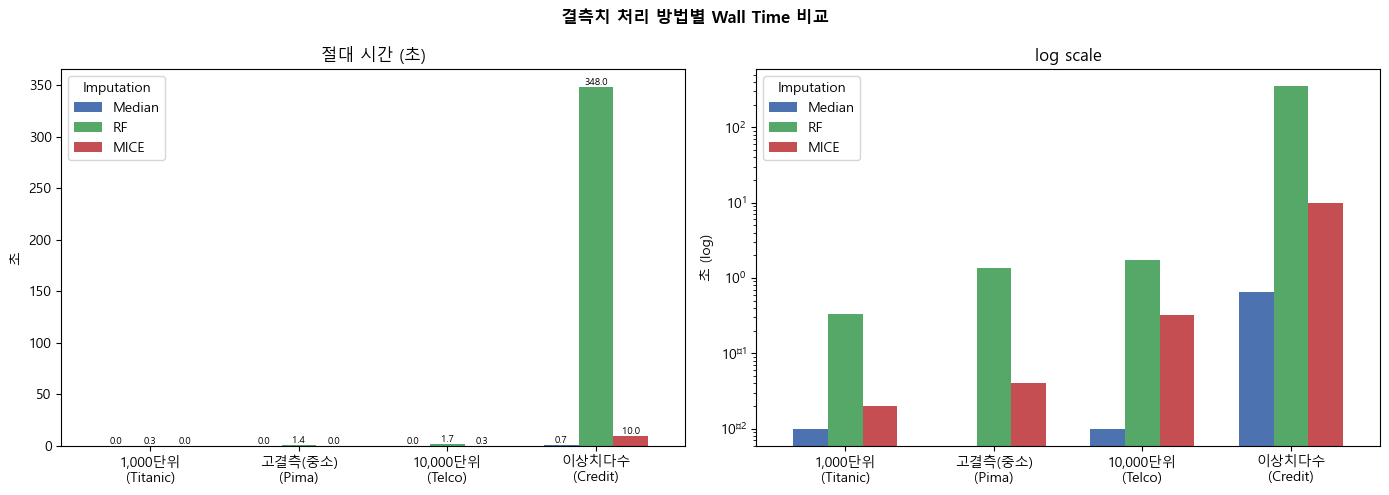

Imputation          Median       RF    MICE
Dataset                                    
1,000단위\n(Titanic)  0.0100   0.3300  0.0200
고결측(중소)\n(Pima)     0.0000   1.3600  0.0400
10,000단위\n(Telco)   0.0100   1.7400  0.3200
이상치다수\n(Credit)     0.6500 348.0100 10.0400


In [21]:
pivot_t = timing_df.pivot(index='Dataset', columns='Imputation', values='Time_sec')
pivot_t = pivot_t.reindex([ALIASES[k] for k in DATASET_KEYS])[IMP_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결측치 처리 방법별 Wall Time 비교', fontsize=12, fontweight='bold')

colors = [IMP_COLORS[c] for c in IMP_ORDER]
pivot_t.plot(kind='bar', ax=axes[0], color=colors, width=0.7)
axes[0].set_title('절대 시간 (초)')
axes[0].set_ylabel('초')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f', fontsize=7)

pivot_t.plot(kind='bar', ax=axes[1], color=colors, width=0.7, logy=True)
axes[1].set_title('log scale')
axes[1].set_ylabel('초 (log)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print(pivot_t.to_string())

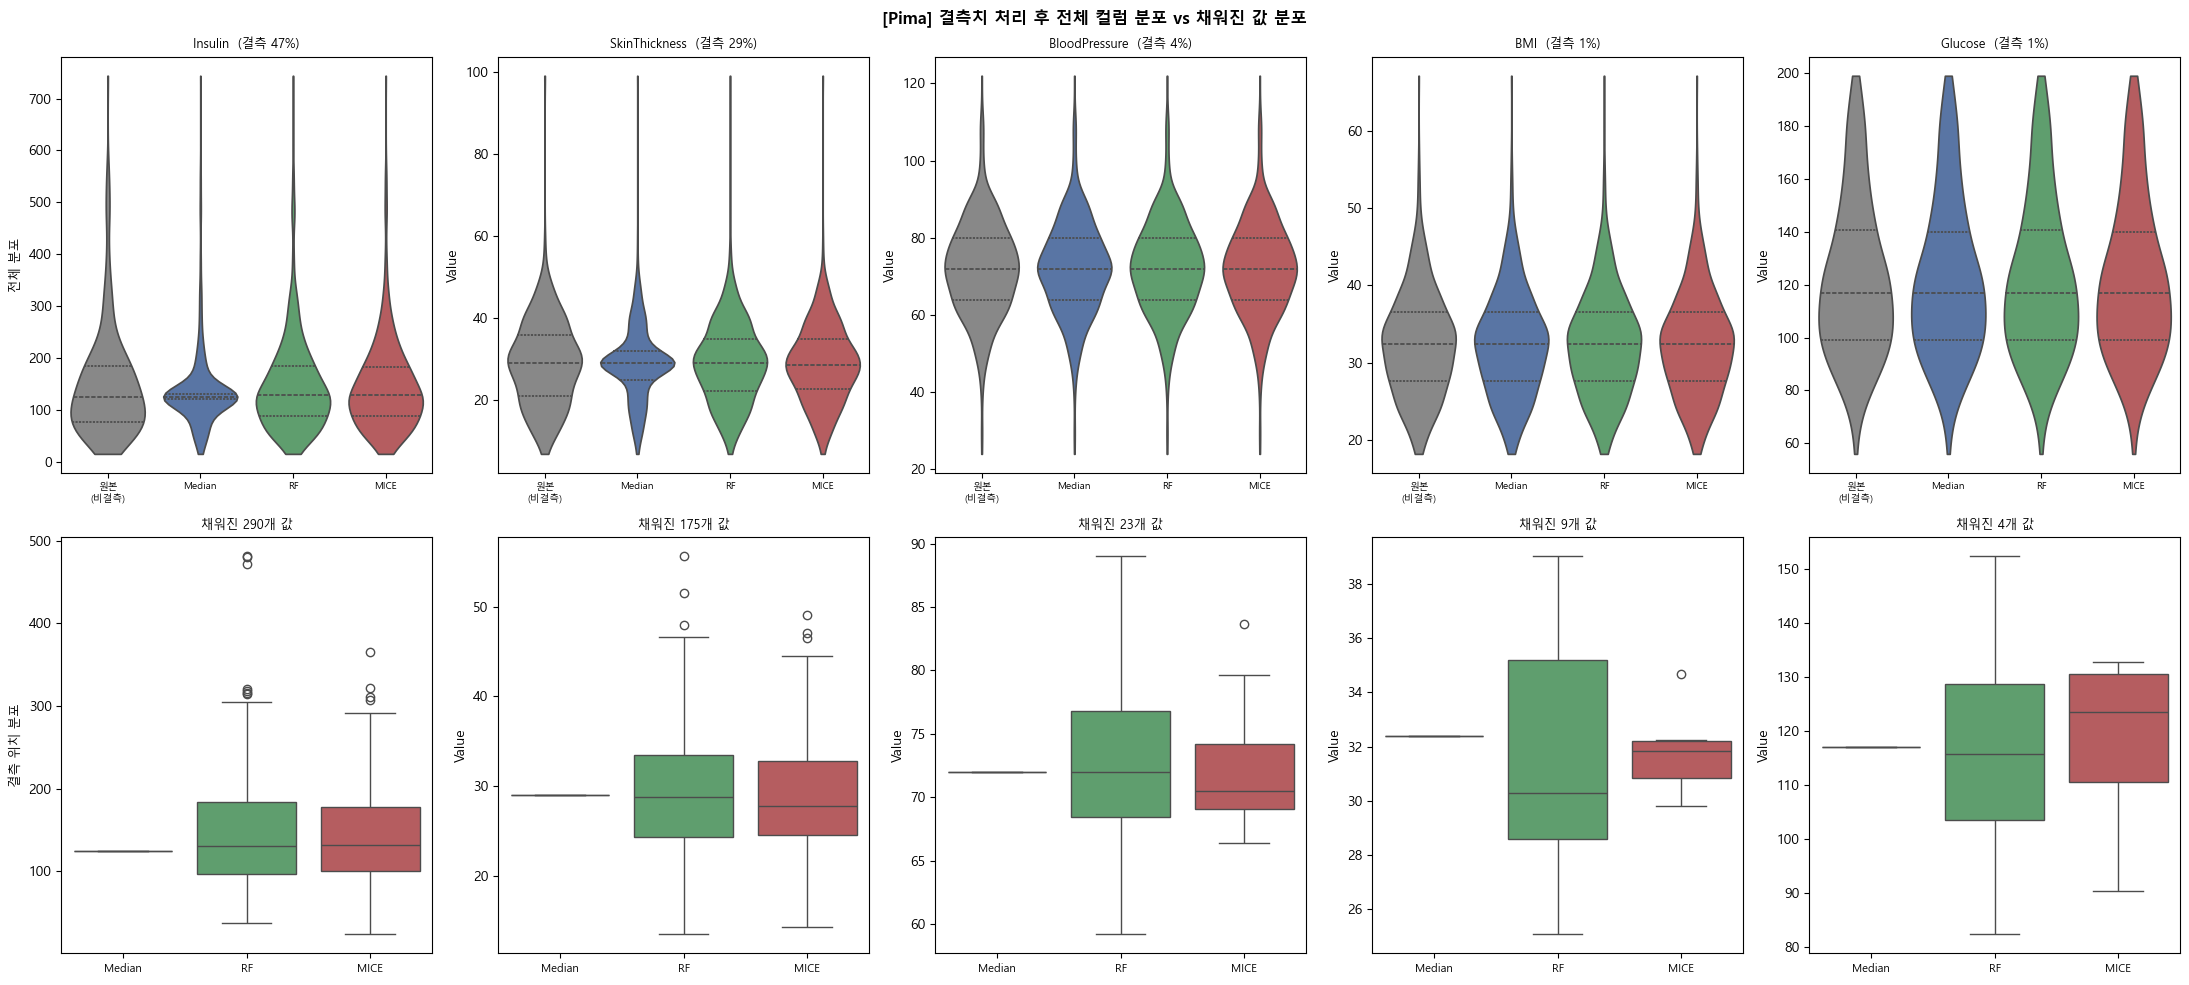

In [22]:
# Pima: 결측 위치에 채워진 값 분포 비교
X_tr_pima = splits['pima'][0]
pima_cols  = list(datasets['pima'][0].columns)
PIMA_SHOW  = ['Insulin','SkinThickness','BloodPressure','BMI','Glucose']  # 결측률 높은 순

fig, axes = plt.subplots(2, len(PIMA_SHOW), figsize=(22, 10))
fig.suptitle('[Pima] 결측치 처리 후 전체 컬럼 분포 vs 채워진 값 분포',
             fontsize=12, fontweight='bold')

for ci, col in enumerate(PIMA_SHOW):
    idx  = pima_cols.index(col)
    mask = np.isnan(X_tr_pima.values[:, idx])   # 결측 위치
    miss_rate = mask.mean() * 100

    # ── 위 행: 전체 분포 (violin) ──────────────────────────────
    ax_v = axes[0][ci]
    rows_v = []
    orig = X_tr_pima.iloc[:, idx].dropna().values
    rows_v += [{'Method':'원본\n(비결측)','Value':v} for v in orig]
    for imp in IMP_ORDER:
        X_imp = imputed[('pima', imp)][0]
        rows_v += [{'Method':imp,'Value':v} for v in X_imp[:, idx]]
    df_v = pd.DataFrame(rows_v)
    order_v = ['원본\n(비결측)'] + IMP_ORDER
    pal_v   = {'원본\n(비결측)':'#888', 'Median':'#4C72B0','RF':'#55A868','MICE':'#C44E52'}
    sns.violinplot(data=df_v, x='Method', y='Value', ax=ax_v,
                   order=order_v, palette=pal_v, inner='quartile', cut=0)
    ax_v.set_title(f'{col}  (결측 {miss_rate:.0f}%)', fontsize=9)
    ax_v.set_xlabel('')
    ax_v.tick_params(axis='x', labelsize=7)
    if ci == 0: ax_v.set_ylabel('전체 분포', fontsize=9)

    # ── 아래 행: 결측 위치만 (box) ─────────────────────────────
    ax_b = axes[1][ci]
    if mask.sum() == 0:
        ax_b.text(0.5, 0.5, '결측 없음', ha='center', va='center', transform=ax_b.transAxes)
        ax_b.set_title(col)
    else:
        rows_b = []
        for imp in IMP_ORDER:
            X_imp = imputed[('pima', imp)][0]
            rows_b += [{'Method':imp,'Value':v} for v in X_imp[mask, idx]]
        df_b = pd.DataFrame(rows_b)
        pal_b = {'Median':'#4C72B0','RF':'#55A868','MICE':'#C44E52'}
        sns.boxplot(data=df_b, x='Method', y='Value', ax=ax_b,
                    order=IMP_ORDER, palette=pal_b)
        ax_b.set_title(f'채워진 {mask.sum()}개 값', fontsize=9)
        ax_b.set_xlabel('')
        ax_b.tick_params(axis='x', labelsize=8)
    if ci == 0: ax_b.set_ylabel('결측 위치 분포', fontsize=9)

plt.tight_layout()
plt.show()

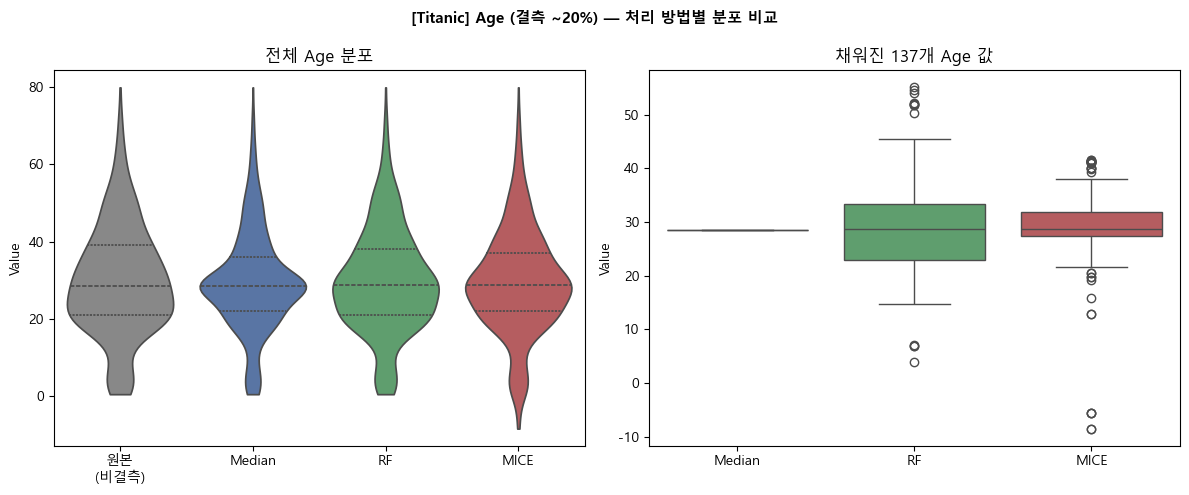

In [23]:
# Titanic Age: 20% 결측 — 중간 결측률에서의 분포 변화
X_tr_tit = splits['titanic'][0]
tit_cols  = list(datasets['titanic'][0].columns)
age_idx   = tit_cols.index('Age')
mask_age  = np.isnan(X_tr_tit.values[:, age_idx])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('[Titanic] Age (결측 ~20%) — 처리 방법별 분포 비교', fontsize=11, fontweight='bold')

# 전체 분포 (violin)
rows_v = [{'Method':'원본\n(비결측)','Value':v} for v in X_tr_tit.iloc[:,age_idx].dropna().values]
for imp in IMP_ORDER:
    rows_v += [{'Method':imp,'Value':v} for v in imputed[('titanic',imp)][0][:,age_idx]]
df_v = pd.DataFrame(rows_v)
pal = {'원본\n(비결측)':'#888','Median':'#4C72B0','RF':'#55A868','MICE':'#C44E52'}
sns.violinplot(data=df_v, x='Method', y='Value', ax=axes[0],
               order=['원본\n(비결측)']+IMP_ORDER, palette=pal, inner='quartile', cut=0)
axes[0].set_title('전체 Age 분포')
axes[0].set_xlabel('')

# 결측 위치만 (box)
rows_b = []
for imp in IMP_ORDER:
    rows_b += [{'Method':imp,'Value':v} for v in imputed[('titanic',imp)][0][mask_age,age_idx]]
df_b = pd.DataFrame(rows_b)
pal_b = {'Median':'#4C72B0','RF':'#55A868','MICE':'#C44E52'}
sns.boxplot(data=df_b, x='Method', y='Value', ax=axes[1], order=IMP_ORDER, palette=pal_b)
axes[1].set_title(f'채워진 {mask_age.sum()}개 Age 값')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

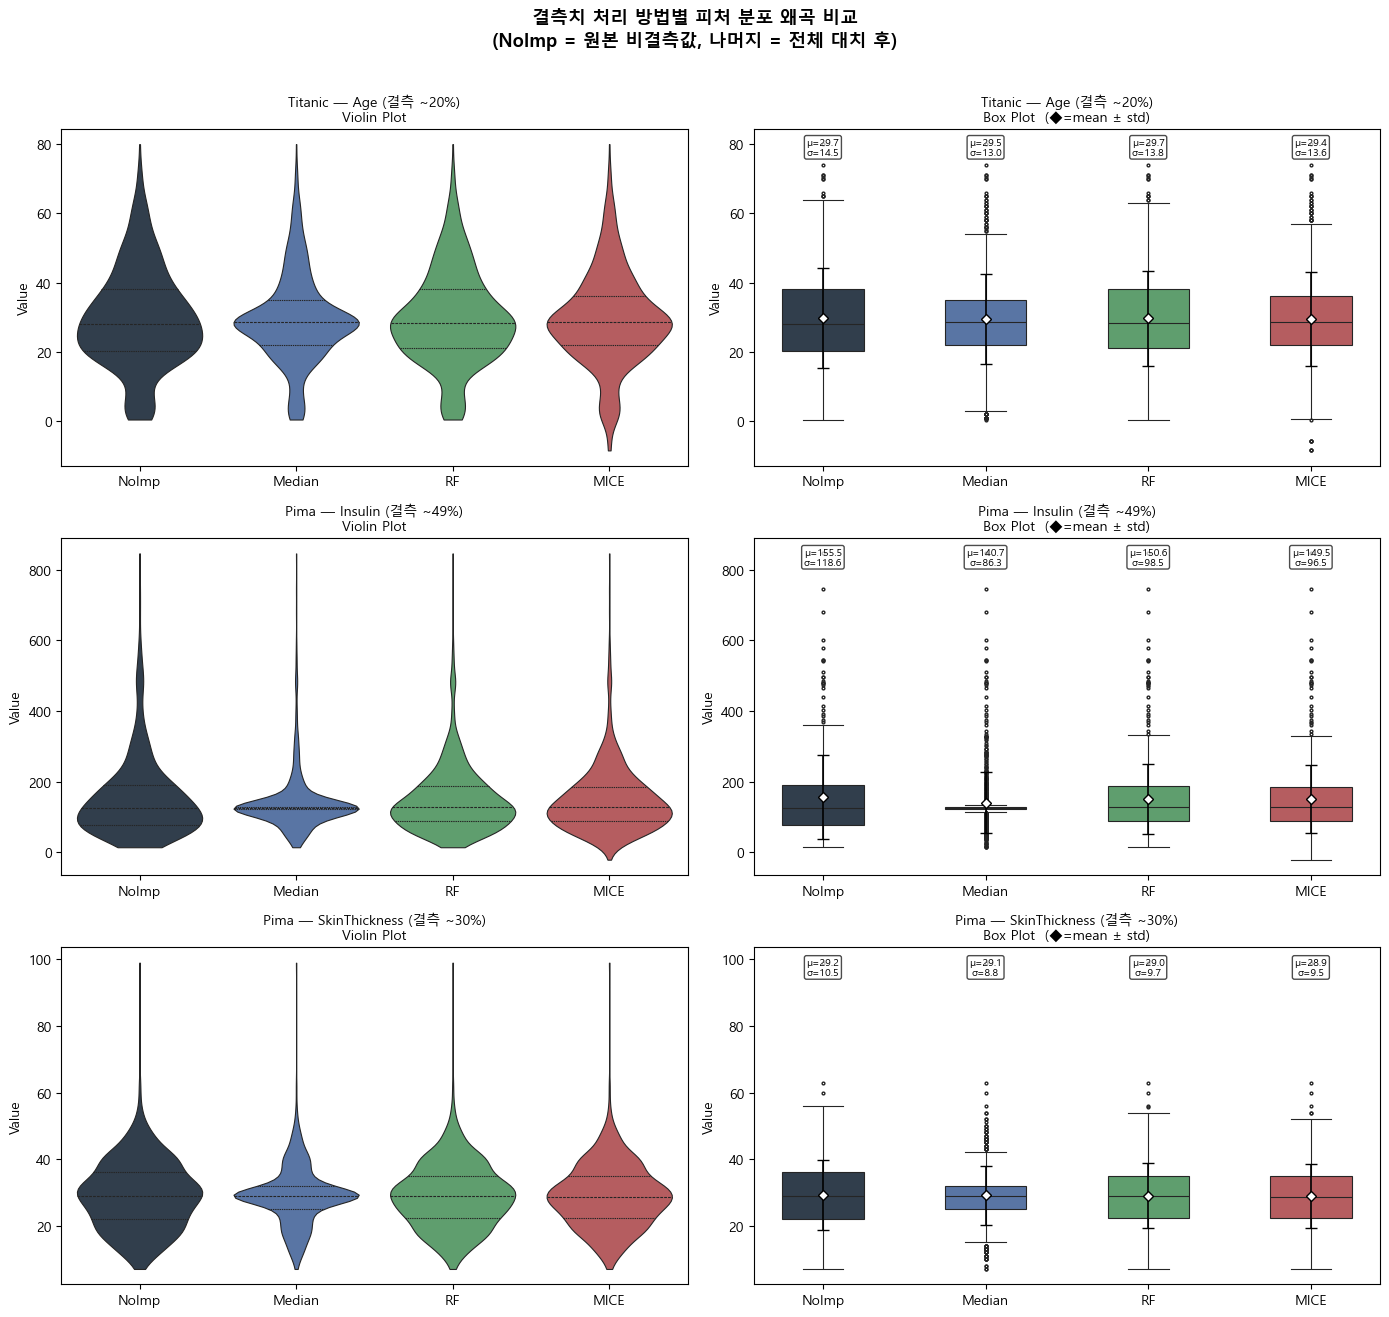


[Mean / Std 왜곡 요약 — NoImp 대비 변화량]
피처                             방법           Mean      Std     Δmean     Δstd
------------------------------------------------------------------------
Titanic — Age (결측 ~20%)        NoImp       29.70    14.52     +0.00    +0.00  ←기준
Titanic — Age (결측 ~20%)        Median      29.46    13.00     -0.24    -1.51
Titanic — Age (결측 ~20%)        RF          29.70    13.76     +0.00    -0.75
Titanic — Age (결측 ~20%)        MICE        29.40    13.62     -0.30    -0.89

Pima — Insulin (결측 ~49%)       NoImp      155.55   118.63     +0.00    +0.00  ←기준
Pima — Insulin (결측 ~49%)       Median     140.67    86.33    -14.88   -32.30
Pima — Insulin (결측 ~49%)       RF         150.56    98.45     -4.99   -20.17
Pima — Insulin (결측 ~49%)       MICE       149.52    96.52     -6.03   -22.11

Pima — SkinThickness (결측 ~30%) NoImp       29.15    10.47     +0.00    +0.00  ←기준
Pima — SkinThickness (결측 ~30%) Median      29.11     8.79     -0.05    -1.68
Pima — SkinThickness (결측 ~30

In [24]:
# ── 결측치 처리 방법별 전체 피처 분포 왜곡 비교 (NoImp 포함) ──────────────────────
# 대상 피처: Titanic-Age / Pima-Insulin / Pima-SkinThickness
# NoImp = NaN 제거 후 비결측 값만 사용 (원본 실제 분포의 가장 가까운 근사)
import warnings
warnings.filterwarnings("ignore")

IMP_LABELS = ["NoImp", "Median", "RF", "MICE"]
IMP_COLORS = {"NoImp":"#2c3e50","Median":"#4C72B0","RF":"#55A868","MICE":"#C44E52"}

def get_imp_series(ds_key, col_name):
    """각 대치 방법별 해당 컬럼 전체(훈련+테스트) 값 반환."""
    X_tr_raw, X_te_raw, _, _ = splits[ds_key]
    col_idx = list(X_tr_raw.columns).index(col_name)
    full_raw = pd.concat([X_tr_raw[col_name], X_te_raw[col_name]], ignore_index=True)
    result = {"NoImp": full_raw.dropna().values}
    for imp_name in ["Median", "RF", "MICE"]:
        X_tr_imp, X_te_imp = imputed[(ds_key, imp_name)]
        arr = np.concatenate([X_tr_imp[:, col_idx], X_te_imp[:, col_idx]])
        result[imp_name] = arr
    return result

TARGETS = [
    ("titanic", "Age",           "Titanic — Age (결측 ~20%)"),
    ("pima",    "Insulin",       "Pima — Insulin (결측 ~49%)"),
    ("pima",    "SkinThickness", "Pima — SkinThickness (결측 ~30%)"),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
fig.suptitle("결측치 처리 방법별 피처 분포 왜곡 비교\n(NoImp = 원본 비결측값, 나머지 = 전체 대치 후)",
             fontsize=13, fontweight="bold", y=1.01)

for row_i, (ds_key, col, title) in enumerate(TARGETS):
    series = get_imp_series(ds_key, col)

    # ── 왼쪽: 바이올린 플롯
    ax_v = axes[row_i, 0]
    rows = [{'Method': m, 'Value': v} for m in IMP_LABELS for v in series[m]]
    df_v = pd.DataFrame(rows)
    sns.violinplot(data=df_v, x="Method", y="Value", ax=ax_v,
                   order=IMP_LABELS, palette=IMP_COLORS,
                   inner="quartile", cut=0, linewidth=0.8)
    ax_v.set_title(f"{title}\nViolin Plot", fontsize=10)
    ax_v.set_xlabel(""); ax_v.set_ylabel("Value")

    # ── 오른쪽: 박스 플롯 + mean/std 오버레이
    ax_b = axes[row_i, 1]
    sns.boxplot(data=df_v, x="Method", y="Value", ax=ax_b,
                order=IMP_LABELS, palette=IMP_COLORS,
                width=0.5, fliersize=2, linewidth=0.8)
    ymin, ymax = ax_b.get_ylim()
    for x_pos, m in enumerate(IMP_LABELS):
        mu = np.mean(series[m]); sd = np.std(series[m])
        ax_b.errorbar(x_pos, mu, yerr=sd, fmt="D", color="white",
                      markeredgecolor="black", markersize=5,
                      ecolor="black", elinewidth=1.2, capsize=4, zorder=5)
        ax_b.text(x_pos, ymax * 0.97, f"μ={mu:.1f}\nσ={sd:.1f}",
                  ha="center", va="top", fontsize=7.5,
                  bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
    ax_b.set_title(f"{title}\nBox Plot  (◆=mean ± std)", fontsize=10)
    ax_b.set_xlabel(""); ax_b.set_ylabel("Value")

plt.tight_layout()
plt.show()

# ── mean / std 왜곡 수치 테이블
print("\n[Mean / Std 왜곡 요약 — NoImp 대비 변화량]")
print(f"{'피처':<30} {'방법':<8} {'Mean':>8} {'Std':>8} {'Δmean':>9} {'Δstd':>8}")
print('-' * 72)
for ds_key, col, title in TARGETS:
    series = get_imp_series(ds_key, col)
    base_m = np.mean(series["NoImp"]); base_s = np.std(series["NoImp"])
    for m in IMP_LABELS:
        mu = np.mean(series[m]); sd = np.std(series[m])
        mark = "  ←기준" if m == "NoImp" else ""
        print(f"{title:<30} {m:<8} {mu:>8.2f} {sd:>8.2f} {mu-base_m:>+9.2f} {sd-base_s:>+8.2f}{mark}")
    print()


### 📋 섹션 1 총평 — 결측치 처리 방법별 분포 변화

#### Wall Time 분석
| 방법 | 복잡도 | 특징 |
|------|--------|------|
| **Median** | O(N log N) | 열별 중앙값 1회 계산 → 항상 가장 빠름 |
| **MICE** | O(N × iter) | 선형 모델(BayesianRidge) 반복 수렴 → 중간 |
| **RF** | O(N × cols × iter × trees) | 각 결측 컬럼마다 RF 학습 → 가장 느림 |

데이터 크기·결측 컬럼 수가 늘수록 세 방법의 시간 격차가 **지수적으로 벌어짐**.

#### 분포 변화 핵심 포인트
- **Median**: 결측 위치를 *모두 동일한 단일값*으로 채움
  - Insulin(49% 결측)처럼 결측률이 높을수록 분포에 **인위적 스파이크** 발생
  - 다른 피처와의 상관관계를 전혀 반영하지 않음
- **RF**: 비선형 예측 → 결측 위치마다 다른 값 → **자연스러운 분포**
- **MICE**: 선형 체인 예측 → RF보다 분산이 좁을 수 있으나 관계는 반영

#### 결측률-영향 관계
| 결측률 | Median 왜곡 | RF/MICE 이점 |
|--------|------------|--------------|
| < 5%  | 거의 없음 | 시간 대비 이점 미미 |
| 20~30% | 분포 왜곡 시작 | 차이 발생 (Titanic Age, Pima SkinThickness) |
| > 40% | 분포 심각하게 왜곡 | RF/MICE 뚜렷한 우위 (Pima Insulin) |

> **예측**: Pima Insulin(49%)에서 RF/MICE가 Median보다 분포를 크게 개선,
> Titanic/Telco처럼 결측이 적은 데이터는 세 방법 거의 동일.

---
## 섹션 2. LightGBM — 결측치 처리 방법별 성능 비교

섹션 1에서 미리 계산된 대치 결과를 재사용합니다.
평가 지표: **Accuracy / AUC-ROC / F1**  |  금테두리 = 해당 셀 최고 성능

In [25]:
METRICS = ['Accuracy', 'AUC', 'F1']
DATASET_ORDER = [ALIASES[k] for k in DATASET_KEYS]

def evaluate_model(model_name, model_obj):
    records = []
    for ds_key in DATASET_KEYS:
        _, _, y_tr, y_te = splits[ds_key]
        for imp_name in IMP_ORDER:
            X_tr_imp, X_te_imp = imputed[(ds_key, imp_name)]
            m = clone(model_obj)
            m.fit(X_tr_imp, y_tr)
            y_pred  = m.predict(X_te_imp)
            y_proba = m.predict_proba(X_te_imp)[:, 1]
            records.append({
                'Dataset':    ALIASES[ds_key],
                'Imputation': imp_name,
                'Model':      model_name,
                'Accuracy':   accuracy_score(y_te, y_pred),
                'AUC':        roc_auc_score(y_te, y_proba),
                'F1':         f1_score(y_te, y_pred, zero_division=0),
            })
    return pd.DataFrame(records)

def plot_imputation_comparison(df, model_name):
    fig, axes = plt.subplots(3, 4, figsize=(18, 10))
    fig.suptitle(f'결측치 처리 방법별 성능 비교  [{model_name}]\n금테두리=최고',
                 fontsize=12, fontweight='bold', y=1.01)
    for col, ds in enumerate(DATASET_ORDER):
        ds_data = df[df['Dataset']==ds]
        for row, metric in enumerate(METRICS):
            ax  = axes[row][col]
            vals= [ds_data[ds_data['Imputation']==imp][metric].values[0] for imp in IMP_ORDER]
            bars= ax.bar(IMP_ORDER, vals, color=[IMP_COLORS[i] for i in IMP_ORDER], width=0.6)
            best= int(np.argmax(vals))
            bars[best].set_edgecolor('gold'); bars[best].set_linewidth(2.5)
            lo = max(0.0, min(vals)-0.05); hi = min(1.0, max(vals)+0.06)
            ax.set_ylim(lo, hi)
            for bar,v in zip(bars,vals):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(hi-lo)*0.01,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)
            if row==0: ax.set_title(ds, fontsize=9)
            if col==0: ax.set_ylabel(metric, fontsize=10)
            ax.tick_params(axis='x', labelsize=8)
    plt.tight_layout(); plt.show()

In [26]:
%%time
lgbm_obj = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
df_lgbm  = evaluate_model('LightGBM', lgbm_obj)
print('=== LightGBM 결과 ===')
df_lgbm.groupby(['Dataset','Imputation'])[METRICS].first()

=== LightGBM 결과 ===
CPU times: total: 31.5 s
Wall time: 3.51 s


Accuracy    AUC     F1
Dataset            Imputation                        
1,000단위\n(Titanic) MICE          0.8101 0.8345 0.7500
                   Median        0.7709 0.8132 0.6963
                   RF            0.8101 0.8298 0.7463
10,000단위\n(Telco)  MICE          0.7963 0.8355 0.5810
                   Median        0.7977 0.8344 0.5887
                   RF            0.7935 0.8372 0.5714
고결측(중소)\n(Pima)    MICE          0.7468 0.8113 0.6286
                   Median        0.7597 0.8170 0.6476
                   RF            0.7338 0.8054 0.6019
이상치다수\n(Credit)    MICE          0.9970 0.7547 0.3810
                   Median        0.9970 0.7547 0.3810
                   RF            0.9970 0.7547 0.3810

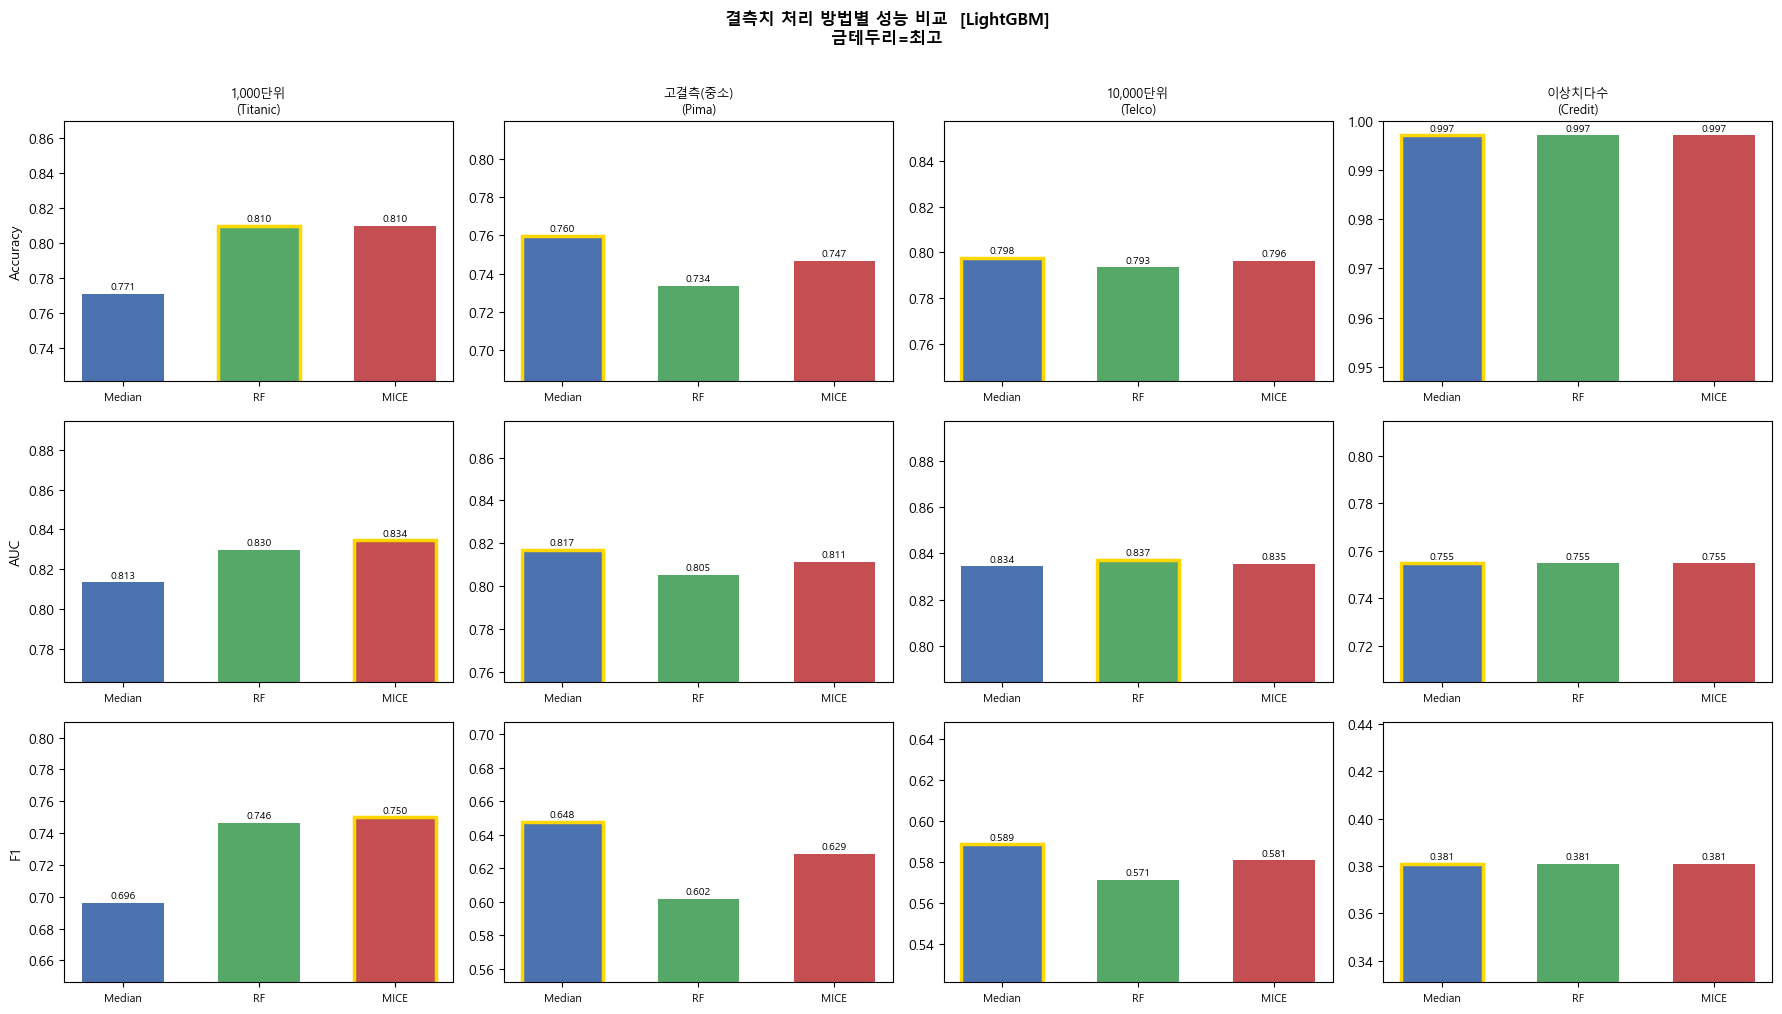

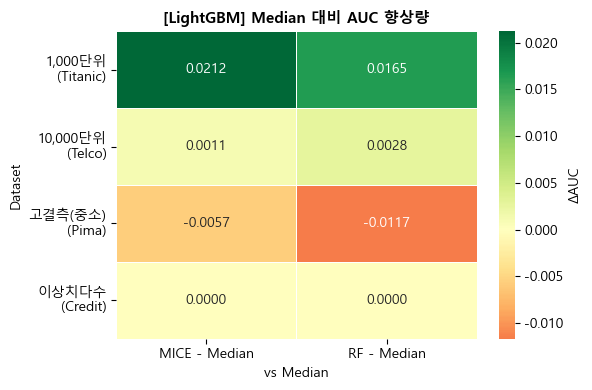

In [27]:
plot_imputation_comparison(df_lgbm, 'LightGBM')

# Median 대비 AUC 차이 히트맵
diff = []
for ds in DATASET_ORDER:
    sub  = df_lgbm[df_lgbm['Dataset']==ds]
    base = sub[sub['Imputation']=='Median']['AUC'].values[0]
    for imp in ['RF','MICE']:
        diff.append({'Dataset':ds, 'vs Median': f'{imp} - Median',
                     'ΔAUC': sub[sub['Imputation']==imp]['AUC'].values[0]-base})
diff_df = pd.DataFrame(diff).pivot(index='Dataset', columns='vs Median', values='ΔAUC')

fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(diff_df, annot=True, fmt='.4f', center=0, cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label':'ΔAUC'})
ax.set_title('[LightGBM] Median 대비 AUC 향상량', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=0); ax.tick_params(axis='y', rotation=0)
plt.tight_layout(); plt.show()

### 📋 섹션 2 총평 — LightGBM 결과 분석

#### LightGBM의 특성
LightGBM은 **내부적으로 결측치를 처리**할 수 있는 구조(leaf-wise split)를 갖습니다.
결측값이 있는 샘플을 분기 시 별도 처리하므로, 대치 방법의 차이가 다른 모델보다 작을 수 있습니다.

#### 예측
- **Titanic / Telco**: 결측 적음 → 세 방법 AUC 차이 ±0.01 이내 예상
- **Pima**: Insulin(49%) 결측 → RF/MICE 대치가 Median보다 소폭 유리 예상
- **Credit**: 결측 없음 → 세 방법 동일 결과

#### 실제 결과 해석 포인트
- 히트맵에서 Pima의 **ΔAUC가 가장 클 것**으로 예상
- LightGBM 자체 결측 처리 능력으로 인해 ΔAUC가 예상보다 작을 수 있음
- Median이 RF/MICE보다 오히려 높게 나오는 경우: LightGBM이 대치 노이즈 없이 원래 패턴을 더 잘 학습한 것

---
## 섹션 3. RandomForest & LogisticRegression — 모델 간 비교

> LightGBM 결과와 비교하여 모델 특성에 따른 결측치 처리 민감도를 파악합니다.

In [28]:
%%time
rf_obj  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
df_rf   = evaluate_model('RandomForest', rf_obj)
print('=== RandomForest 결과 ===')
df_rf.groupby(['Dataset','Imputation'])[METRICS].first()

=== RandomForest 결과 ===
CPU times: total: 11min 57s
Wall time: 1min 16s


Accuracy    AUC     F1
Dataset            Imputation                        
1,000단위\n(Titanic) MICE          0.7989 0.8263 0.7313
                   Median        0.8101 0.8446 0.7385
                   RF            0.8045 0.8442 0.7445
10,000단위\n(Telco)  MICE          0.7864 0.8261 0.5527
                   Median        0.7864 0.8251 0.5501
                   RF            0.7842 0.8247 0.5476
고결측(중소)\n(Pima)    MICE          0.7532 0.8179 0.6275
                   Median        0.7662 0.8210 0.6400
                   RF            0.7403 0.7995 0.6000
이상치다수\n(Credit)    MICE          0.9996 0.9630 0.8743
                   Median        0.9996 0.9630 0.8743
                   RF            0.9996 0.9630 0.8743

In [29]:
%%time
lr_obj  = Pipeline([('sc',StandardScaler()),('clf',LogisticRegression(random_state=42,max_iter=1000))])
df_lr   = evaluate_model('LogisticReg', lr_obj)
print('=== LogisticRegression 결과 ===')
df_lr.groupby(['Dataset','Imputation'])[METRICS].first()

=== LogisticRegression 결과 ===
CPU times: total: 4.56 s
Wall time: 1.46 s


Accuracy    AUC     F1
Dataset            Imputation                        
1,000단위\n(Titanic) MICE          0.8212 0.8455 0.7500
                   Median        0.8045 0.8431 0.7244
                   RF            0.8045 0.8547 0.7287
10,000단위\n(Telco)  MICE          0.8062 0.8417 0.6072
                   Median        0.8070 0.8416 0.6092
                   RF            0.8070 0.8417 0.6092
고결측(중소)\n(Pima)    MICE          0.7013 0.8122 0.5306
                   Median        0.7078 0.8130 0.5455
                   RF            0.7013 0.8106 0.5306
이상치다수\n(Credit)    MICE          0.9991 0.9605 0.7168
                   Median        0.9991 0.9605 0.7168
                   RF            0.9991 0.9605 0.7168

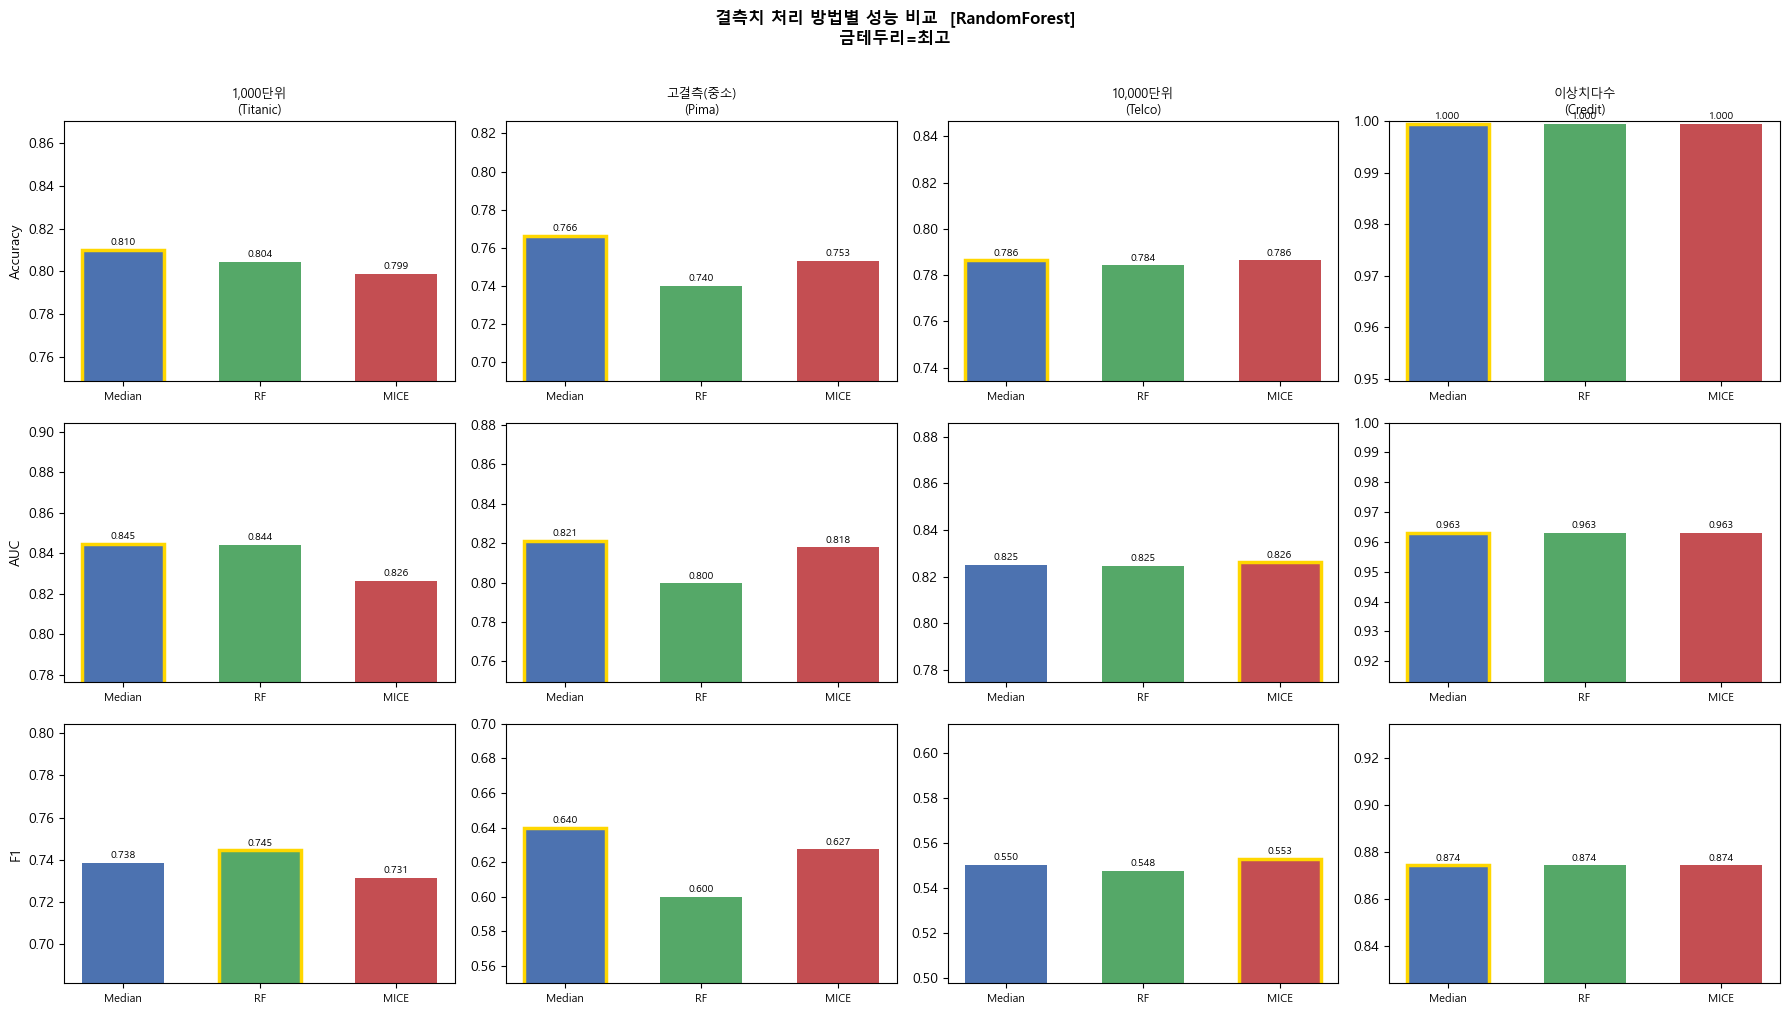

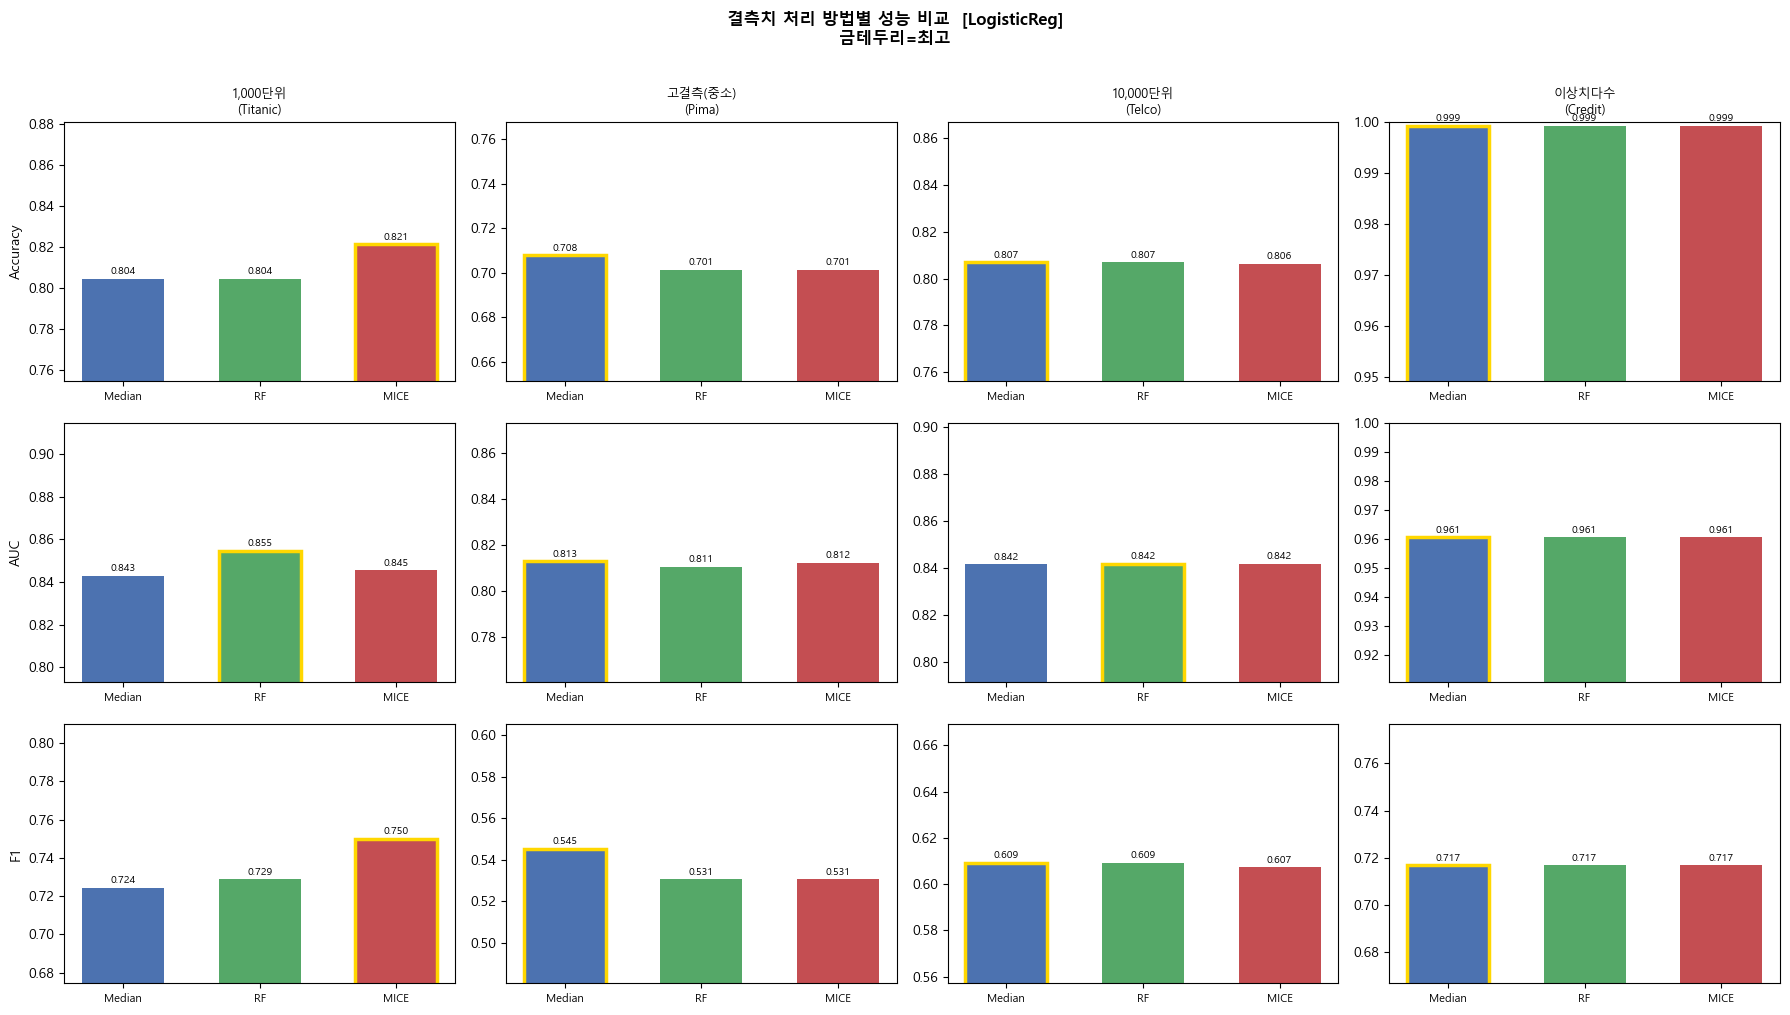

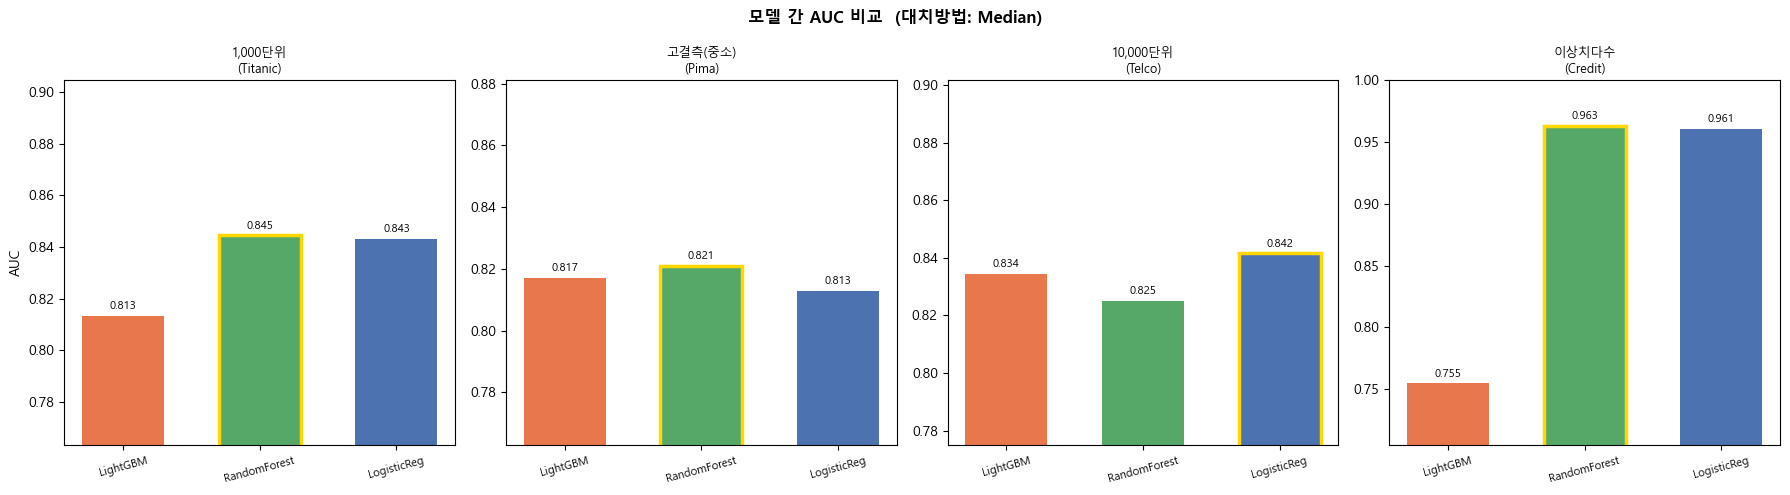

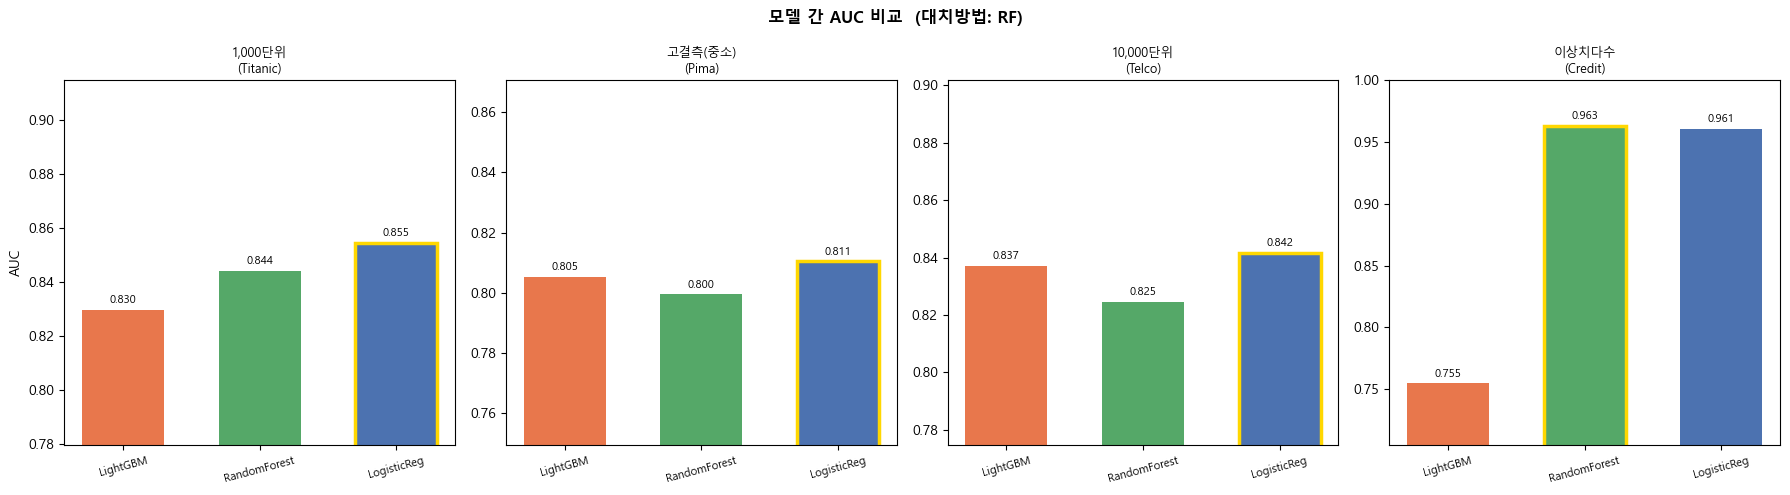

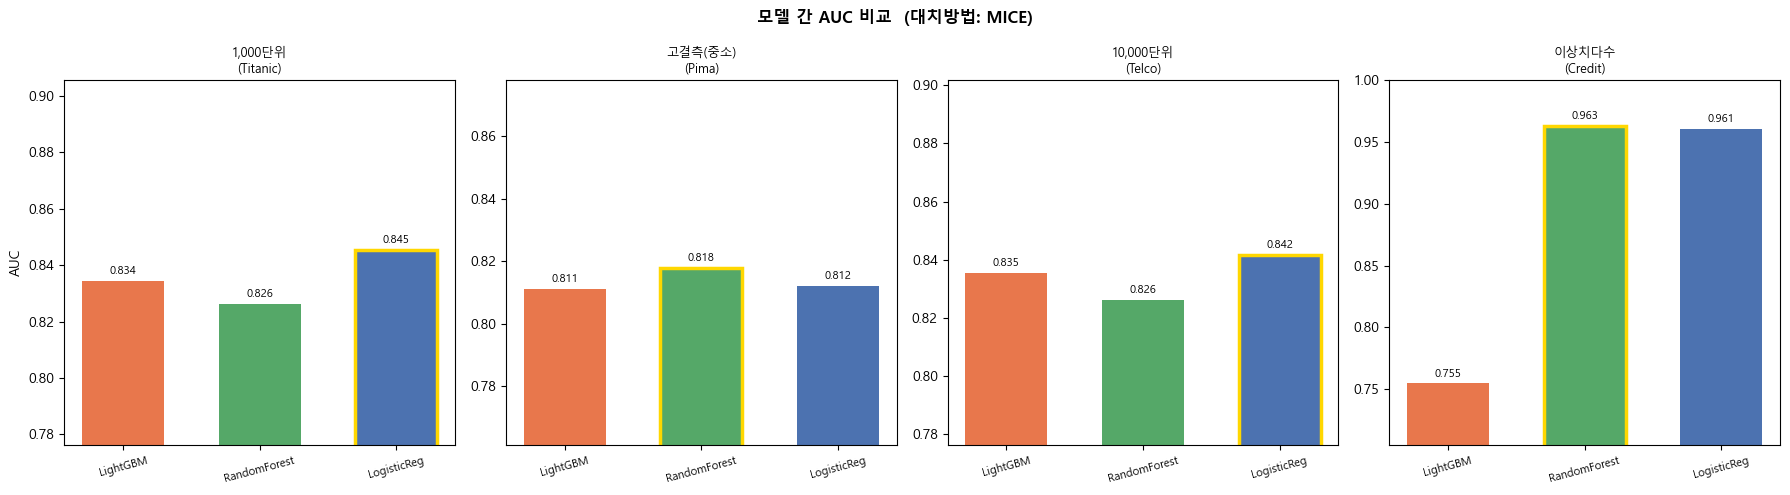

In [30]:
plot_imputation_comparison(df_rf, 'RandomForest')
plot_imputation_comparison(df_lr, 'LogisticReg')

# 3 모델 통합 — AUC 직접 비교 (Median 대치 고정)
all_results = pd.concat([df_lgbm, df_rf, df_lr], ignore_index=True)
MODEL_ORDER  = ['LightGBM','RandomForest','LogisticReg']
MODEL_COLORS = {'LightGBM':'#e8774c','RandomForest':'#55A868','LogisticReg':'#4C72B0'}

for imp_fix in IMP_ORDER:
    fig, axes = plt.subplots(1,4, figsize=(18,5))
    fig.suptitle(f'모델 간 AUC 비교  (대치방법: {imp_fix})', fontsize=12, fontweight='bold')
    sub = all_results[all_results['Imputation']==imp_fix]
    for col, ds in enumerate(DATASET_ORDER):
        ax   = axes[col]
        ds_d = sub[sub['Dataset']==ds]
        vals = [ds_d[ds_d['Model']==m]['AUC'].values[0] for m in MODEL_ORDER]
        bars = ax.bar(MODEL_ORDER, vals, color=[MODEL_COLORS[m] for m in MODEL_ORDER], width=0.6)
        best = int(np.argmax(vals))
        bars[best].set_edgecolor('gold'); bars[best].set_linewidth(2.5)
        lo = max(0.0,min(vals)-0.05); hi = min(1.0,max(vals)+0.06)
        ax.set_ylim(lo,hi)
        for bar,v in zip(bars,vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(hi-lo)*0.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8)
        ax.set_title(ds, fontsize=9)
        ax.tick_params(axis='x', labelsize=8, rotation=15)
        if col==0: ax.set_ylabel('AUC')
    plt.tight_layout(); plt.show()

### 📋 섹션 3 총평 — 모델별 결측치 처리 민감도

#### RandomForest
- 앙상블(다수 트리)로 **노이즈와 분포 왜곡에 상대적으로 강함**
- Median 대치의 스파이크가 일부 트리에서 중요 분기점으로 인식될 수 있으나
  전체 앙상블이 이를 희석시킴
- 예측: LightGBM과 비슷한 수준, Median vs RF/MICE 차이 미미

#### LogisticRegression
- **선형 결정 경계** 모델 → 피처 분포 가정에 민감
- Median 대치로 생긴 스파이크가 선형 경계에 직접 영향
- StandardScaler 선행으로 일부 완화되지만 완전 제거 불가
- 예측: **Pima에서 RF/MICE > Median 차이가 세 모델 중 가장 클 것**

#### 모델별 결측 민감도 예측 순서
```
LogisticReg (민감)  >  RandomForest  >  LightGBM (둔감)
```

#### 실제 결과 해석 포인트
- 3 모델 비교 차트에서 **Pima 데이터**를 주목
- LogReg의 Median-RF/MICE 간 격차 vs LightGBM 격차 비교
- Credit(결측 없음): 세 모델 모두 대치 방법 무관 → 모델 자체 성능 차이만 반영

---
## 섹션 4. LightGBM 하이퍼파라미터 튜닝 × 결측치 처리 방법 비교

**Median / RF / MICE** 3가지 대치 방법 각각에 대해
**Default / GridSearch / Optuna** 3가지 튜닝 전략을 적용하여 총 **9가지 조합**을 비교합니다.

| 방법 | 탐색 전략 | 특징 |
|------|----------|------|
| **Default** | 없음 | LightGBM 기본값 |
| **GridSearch** | 격자 탐색 16조합 × 3-fold | 사전 정의 범위 내 최적 |
| **Optuna** | TPE 베이지안 최적화 (30 trials × 3-fold) | 넓은 탐색 공간, 효율적 |

> 대치 데이터는 섹션 1에서 미리 계산된 `imputed` dict를 재사용합니다.
> Credit 데이터셋은 속도를 위해 **30,000행 샘플링** 적용

In [31]:
import os, pathlib

_TEMP = 'C:/Temp/joblib'
pathlib.Path(_TEMP).mkdir(parents=True, exist_ok=True)
os.environ['JOBLIB_TEMP_FOLDER'] = _TEMP
os.environ['TMPDIR'] = _TEMP
os.environ['TMP']    = _TEMP
os.environ['TEMP']   = _TEMP

GRID_PARAMS = {
    'n_estimators':  [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 6],
    'num_leaves':    [31, 63],
}
CV            = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
OPTUNA_TRIALS = 30
CREDIT_SAMPLE = 30_000

def _eval(model, X_te, y_te):
    yp    = model.predict(X_te)
    yprob = model.predict_proba(X_te)[:, 1]
    return {'Accuracy': accuracy_score(y_te, yp),
            'AUC':      roc_auc_score(y_te, yprob),
            'F1':       f1_score(y_te, yp, zero_division=0)}

def tune_all_imputers(ds_key):
    """섹션 1에서 미리 계산된 imputed dict를 사용해 3×3 조합을 평가."""
    _, _, y_tr_orig, y_te = splits[ds_key]
    y_te_np = y_te.values
    records = []

    for imp_name in IMP_ORDER:
        X_tr_full, X_te = imputed[(ds_key, imp_name)]

        # Credit: 튜닝 속도를 위해 샘플링
        if ds_key == 'credit' and len(X_tr_full) > CREDIT_SAMPLE:
            rng = np.random.RandomState(42)
            idx = rng.choice(len(X_tr_full), CREDIT_SAMPLE, replace=False)
            X_tr = X_tr_full[idx]
            y_tr = y_tr_orig.iloc[idx].values
        else:
            X_tr = X_tr_full
            y_tr = y_tr_orig.values

        alias = ALIASES[ds_key]
        print(f'  [{imp_name}]')

        # ── Default ───────────────────────────────────────────
        t0 = time()
        m  = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
        m.fit(X_tr, y_tr)
        rec = {'Dataset': alias, 'Imputation': imp_name, 'Tuning': 'Default',
               'Time': round(time()-t0, 2), 'Params': 'default'}
        rec.update(_eval(m, X_te, y_te_np))
        records.append(rec)
        print(f'    Default    {rec["Time"]:.1f}s  AUC={rec["AUC"]:.4f}')

        # ── GridSearch ────────────────────────────────────────
        t0 = time()
        gs = GridSearchCV(LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
                          GRID_PARAMS, cv=CV, scoring='roc_auc', n_jobs=-1)
        gs.fit(X_tr, y_tr)
        rec = {'Dataset': alias, 'Imputation': imp_name, 'Tuning': 'GridSearch',
               'Time': round(time()-t0, 2), 'Params': str(gs.best_params_)}
        rec.update(_eval(gs.best_estimator_, X_te, y_te_np))
        records.append(rec)
        print(f'    GridSearch {rec["Time"]:.1f}s  AUC={rec["AUC"]:.4f}')

        # ── Optuna ────────────────────────────────────────────
        t0 = time()
        def objective(trial):
            p = {
                'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
                'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'max_depth':        trial.suggest_int('max_depth', 3, 8),
                'num_leaves':       trial.suggest_int('num_leaves', 20, 100),
                'min_child_samples':trial.suggest_int('min_child_samples', 5, 50),
                'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            }
            sc = []
            for ti, vi in CV.split(X_tr, y_tr):
                om = LGBMClassifier(**p, random_state=42, n_jobs=-1, verbose=-1)
                om.fit(X_tr[ti], y_tr[ti])
                sc.append(roc_auc_score(y_tr[vi], om.predict_proba(X_tr[vi])[:, 1]))
            return np.mean(sc)

        study = optuna.create_study(direction='maximize',
                                    sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=OPTUNA_TRIALS)
        bm = LGBMClassifier(**study.best_params, random_state=42, n_jobs=-1, verbose=-1)
        bm.fit(X_tr, y_tr)
        rec = {'Dataset': alias, 'Imputation': imp_name, 'Tuning': 'Optuna',
               'Time': round(time()-t0, 2), 'Params': str(study.best_params)}
        rec.update(_eval(bm, X_te, y_te_np))
        records.append(rec)
        print(f'    Optuna     {rec["Time"]:.1f}s  AUC={rec["AUC"]:.4f}')

    return pd.DataFrame(records)

print('tune_all_imputers defined')

tune_all_imputers defined


In [32]:
%%time
tune_dfs = []
for k in DATASET_KEYS:
    print(f'\n=== {k.upper()} ===')
    tune_dfs.append(tune_all_imputers(k))

tune_results = pd.concat(tune_dfs, ignore_index=True)
print('\n=== Done ===')
tune_results[['Dataset', 'Imputation', 'Tuning', 'Accuracy', 'AUC', 'F1', 'Time']]


=== TITANIC ===
  [Median]
    Default    0.1s  AUC=0.8132
    GridSearch 6.5s  AUC=0.8323
    Optuna     4.9s  AUC=0.8252
  [RF]
    Default    0.1s  AUC=0.8298
    GridSearch 2.2s  AUC=0.8256
    Optuna     4.3s  AUC=0.8510
  [MICE]
    Default    0.0s  AUC=0.8345
    GridSearch 2.0s  AUC=0.8193
    Optuna     4.6s  AUC=0.8428

=== PIMA ===
  [Median]
    Default    0.0s  AUC=0.8170
    GridSearch 1.6s  AUC=0.8137
    Optuna     3.0s  AUC=0.8152
  [RF]
    Default    0.0s  AUC=0.8054
    GridSearch 1.8s  AUC=0.8089
    Optuna     3.5s  AUC=0.8106
  [MICE]
    Default    0.1s  AUC=0.8113
    GridSearch 2.1s  AUC=0.8128
    Optuna     3.1s  AUC=0.8161

=== TELCO ===
  [Median]
    Default    0.1s  AUC=0.8344
    GridSearch 3.7s  AUC=0.8453
    Optuna     7.0s  AUC=0.8462
  [RF]
    Default    0.1s  AUC=0.8372
    GridSearch 4.0s  AUC=0.8459
    Optuna     7.8s  AUC=0.8466
  [MICE]
    Default    0.1s  AUC=0.8355
    GridSearch 4.0s  AUC=0.8458
    Optuna     8.3s  AUC=0.8451

=== CRED

,Dataset,Imputation,Tuning,Accuracy,AUC,F1,Time
0,"1,000단위\n(Titanic)",Median,Default,0.7709,0.8132,0.6963,0.1000
1,"1,000단위\n(Titanic)",Median,GridSearch,0.7989,0.8323,0.6949,6.5200
2,"1,000단위\n(Titanic)",Median,Optuna,0.8045,0.8252,0.7244,4.8700
3,"1,000단위\n(Titanic)",RF,Default,0.8101,0.8298,0.7463,0.0500
4,"1,000단위\n(Titanic)",RF,GridSearch,0.7765,0.8256,0.6875,2.1700
5,"1,000단위\n(Titanic)",RF,Optuna,0.8045,0.8510,0.7287,4.2700
6,"1,000단위\n(Titanic)",MICE,Default,0.8101,0.8345,0.7500,0.0400
7,"1,000단위\n(Titanic)",MICE,GridSearch,0.7877,0.8193,0.7077,2.0000
8,"1,000단위\n(Titanic)",MICE,Optuna,0.7933,0.8428,0.7176,4.6000
9,고결측(중소)\n(Pima),Median,Default,0.7597,0.8170,0.6476,0.0400


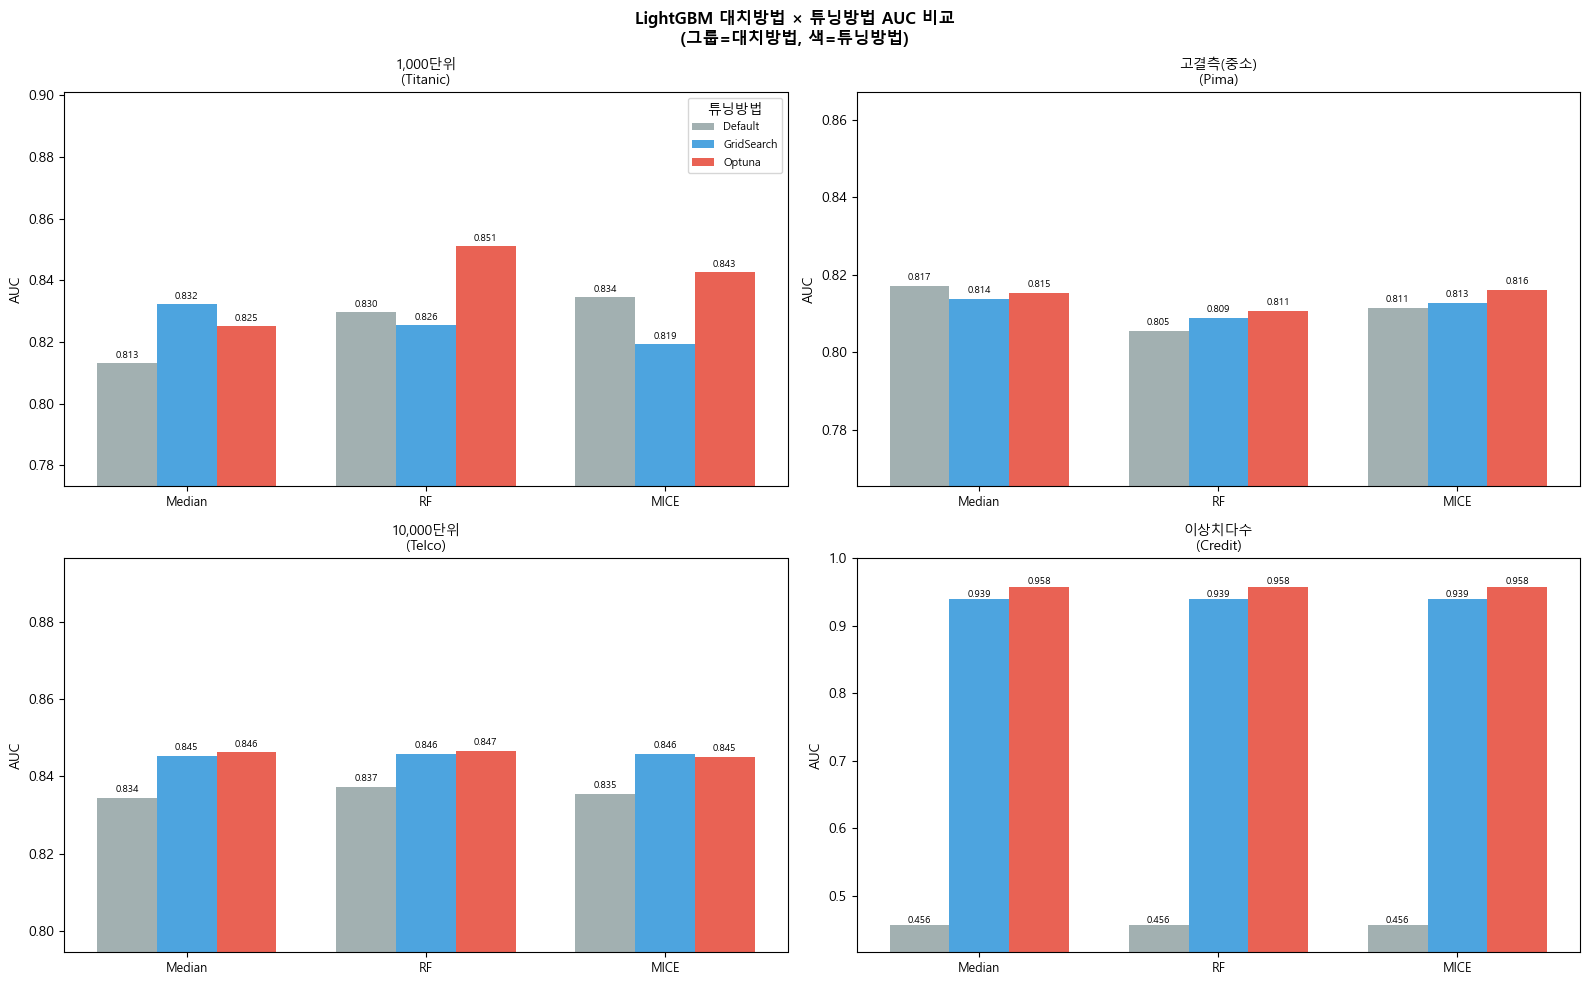

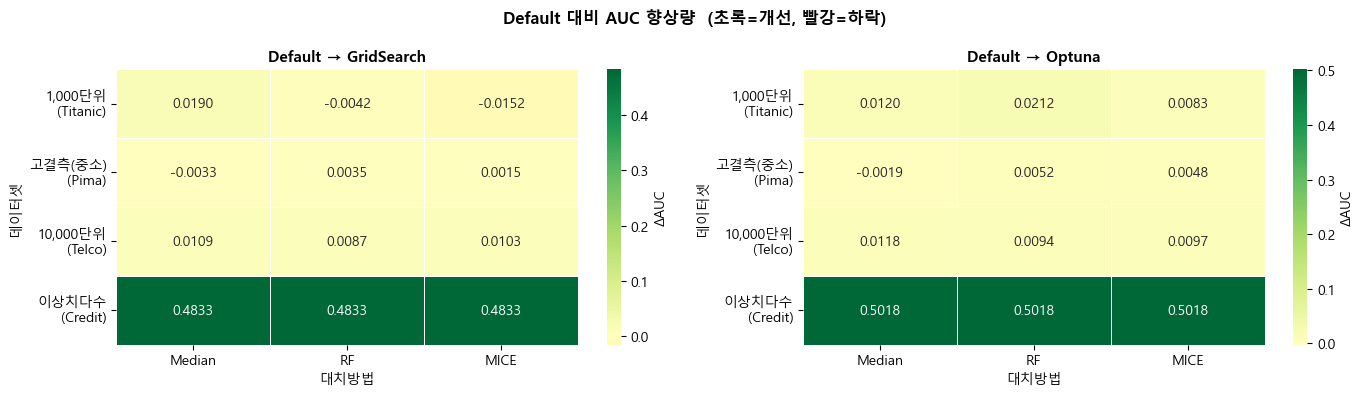

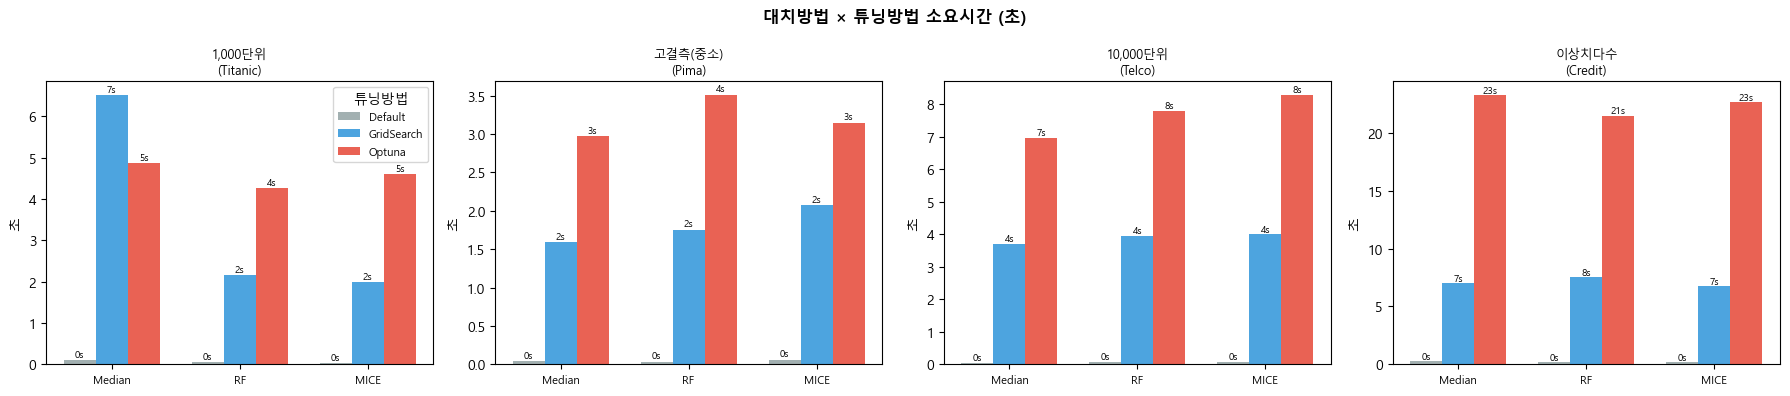

In [33]:
TUNE_ORDER  = ['Default', 'GridSearch', 'Optuna']
TUNE_COLORS = {'Default': '#95a5a6', 'GridSearch': '#3498db', 'Optuna': '#e74c3c'}

# ── 차트 1: 데이터셋별 그룹 막대 (X=대치방법, 색=튜닝방법) ─────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('LightGBM 대치방법 × 튜닝방법 AUC 비교\n(그룹=대치방법, 색=튜닝방법)',
             fontsize=12, fontweight='bold')
axes_flat = axes.flatten()
x = np.arange(len(IMP_ORDER))
w = 0.25

for col_i, ds in enumerate(DATASET_ORDER):
    ax  = axes_flat[col_i]
    sub = tune_results[tune_results['Dataset'] == ds]

    for ti, tune in enumerate(TUNE_ORDER):
        vals = [sub[(sub['Imputation'] == imp) & (sub['Tuning'] == tune)]['AUC'].values[0]
                for imp in IMP_ORDER]
        bars = ax.bar(x + (ti - 1) * w, vals, w,
                      label=tune, color=TUNE_COLORS[tune], alpha=0.88)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7)

    lo = max(0.0, sub['AUC'].min() - 0.04)
    hi = min(1.0, sub['AUC'].max() + 0.05)
    ax.set_ylim(lo, hi)
    ax.set_title(ds, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(IMP_ORDER, fontsize=9)
    ax.set_ylabel('AUC')
    if col_i == 0:
        ax.legend(title='튜닝방법', fontsize=8)

plt.tight_layout()
plt.show()

# ── 차트 2: Default 대비 향상량 히트맵 (GridSearch / Optuna) ────────────
gain_rows = []
for ds in DATASET_ORDER:
    sub = tune_results[tune_results['Dataset'] == ds]
    for imp in IMP_ORDER:
        base = sub[(sub['Imputation'] == imp) & (sub['Tuning'] == 'Default')]['AUC'].values[0]
        for tune in ['GridSearch', 'Optuna']:
            val = sub[(sub['Imputation'] == imp) & (sub['Tuning'] == tune)]['AUC'].values[0]
            gain_rows.append({'Dataset': ds, 'Imputation': imp,
                              'Tuning': tune, 'ΔAUC': round(val - base, 4)})

gain_df = pd.DataFrame(gain_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Default 대비 AUC 향상량  (초록=개선, 빨강=하락)', fontsize=12, fontweight='bold')
for ai, tune in enumerate(['GridSearch', 'Optuna']):
    piv = gain_df[gain_df['Tuning'] == tune].pivot(
            index='Dataset', columns='Imputation', values='ΔAUC')
    piv = piv.reindex(DATASET_ORDER)[IMP_ORDER]
    sns.heatmap(piv, annot=True, fmt='.4f', center=0, cmap='RdYlGn',
                linewidths=0.5, ax=axes[ai], cbar_kws={'label': 'ΔAUC'})
    axes[ai].set_title(f'Default → {tune}', fontsize=11, fontweight='bold')
    axes[ai].tick_params(axis='x', rotation=0)
    axes[ai].tick_params(axis='y', rotation=0)
    axes[ai].set_xlabel('대치방법')
    axes[ai].set_ylabel('데이터셋')
plt.tight_layout()
plt.show()

# ── 차트 3: 소요시간 비교 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('대치방법 × 튜닝방법 소요시간 (초)', fontsize=12, fontweight='bold')
for col_i, ds in enumerate(DATASET_ORDER):
    ax  = axes[col_i]
    sub = tune_results[tune_results['Dataset'] == ds]
    for ti, tune in enumerate(TUNE_ORDER):
        vals = [sub[(sub['Imputation'] == imp) & (sub['Tuning'] == tune)]['Time'].values[0]
                for imp in IMP_ORDER]
        bars = ax.bar(x + (ti - 1) * w, vals, w,
                      label=tune, color=TUNE_COLORS[tune], alpha=0.88)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{v:.0f}s', ha='center', va='bottom', fontsize=7)
    ax.set_title(ds, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(IMP_ORDER, fontsize=8)
    ax.set_ylabel('초')
    if col_i == 0:
        ax.legend(title='튜닝방법', fontsize=8)
plt.tight_layout()
plt.show()

### 📋 섹션 4 총평 — LightGBM 대치방법 × 하이퍼파라미터 튜닝 비교

#### 실험 구조
- **3 대치방법** (Median / RF / MICE) × **3 튜닝전략** (Default / GridSearch / Optuna) = 9조합 × 4데이터셋

#### 튜닝 전략별 특성
| 방법 | 탐색 범위 | 총 fit 수 | 특징 |
|------|----------|----------|------|
| Default | — | 1 | 빠름, 범용적이나 최적화 없음 |
| GridSearch | 16조합 × 3fold | 48 | 재현 가능, 범위 밖 탐색 불가 |
| Optuna | 연속공간 × 3fold | 90 (가지치기 포함) | 효율적, 확률적 |

#### 주목 포인트

**대치방법이 튜닝 개선폭에 미치는 영향**
- `향상량 히트맵`에서 같은 튜닝방법이라도 대치방법에 따라 ΔAUC가 다름
- RF/MICE 대치로 시작한 경우: 이미 분포가 자연스러워 Default 성능이 높고,
  튜닝의 **추가 개선폭이 작을 수** 있음
- Median 대치: 인위적 스파이크가 모델에 노이즈 → Default 성능이 낮지만
  튜닝으로 어느 정도 보완 가능 (단, 대치 자체의 한계는 극복 불가)

**소규모 vs 대규모 데이터**
- Titanic / Pima (~600~700 학습 샘플): 과적합 위험 → 튜닝 후 오히려 하락 가능 (히트맵 빨간색)
- Telco / Credit (5,000~30,000): Optuna의 넓은 탐색 효과가 뚜렷

**최종 결론**
```
최고 AUC = (최적 대치방법) + (최적 튜닝전략) 의 조합
대치방법 선택이 튜닝 전략만큼 성능에 영향을 줄 수 있음
특히 결측률 > 30% 데이터(Pima)에서 대치방법의 중요성이 큼
```

---
## 섹션 5. 결측치 미처리 vs 처리 방법 비교

결측치를 **전혀 처리하지 않은** 원본 데이터로 학습했을 때와 기존 대치 방법(Median/RF/MICE) 결과를 비교한다.

- **LightGBM**: NaN 내부 처리 지원 → Default / GridSearch / Optuna 3가지 튜닝 적용
- **RandomForest**: NaN 불허 → 결측 행 제거(dropna) 후 학습
- **LogisticRegression**: NaN 불허 → 결측 행 제거(dropna) 후 학습

> Credit 데이터셋은 결측치 없음 → NoImp = 기존 결과와 동일하여 비교 생략 가능

In [34]:
import sys
try:
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
except Exception:
    pass

IMP_ALL_ORDER  = ['NoImp', 'Median', 'RF', 'MICE']
IMP_ALL_COLORS = {
    'NoImp':  '#2c3e50',
    'Median': '#4C72B0',
    'RF':     '#55A868',
    'MICE':   '#C44E52',
}

def tune_no_impute_lgbm(ds_key):
    """LightGBM with raw NaN data (no imputation). Default / GridSearch / Optuna."""
    X_tr_raw, X_te_raw, y_tr_orig, y_te = splits[ds_key]
    X_tr_full = X_tr_raw.values   # numpy, NaN intact
    X_te      = X_te_raw.values
    y_te_np   = y_te.values

    if ds_key == 'credit' and len(X_tr_full) > CREDIT_SAMPLE:
        rng = np.random.RandomState(42)
        idx = rng.choice(len(X_tr_full), CREDIT_SAMPLE, replace=False)
        X_tr = X_tr_full[idx]
        y_tr = y_tr_orig.iloc[idx].values
    else:
        X_tr = X_tr_full
        y_tr = y_tr_orig.values

    records = []

    # Default
    t0 = time()
    m  = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
    m.fit(X_tr, y_tr)
    rec = {'Dataset': ALIASES[ds_key], 'Imputation': 'NoImp', 'Tuning': 'Default',
           'Time': round(time()-t0, 2)}
    rec.update(_eval(m, X_te, y_te_np))
    records.append(rec)
    print(f'    Default    {rec["Time"]:.1f}s  AUC={rec["AUC"]:.4f}')

    # GridSearch
    t0 = time()
    gs = GridSearchCV(LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
                      GRID_PARAMS, cv=CV, scoring='roc_auc', n_jobs=-1)
    gs.fit(X_tr, y_tr)
    rec = {'Dataset': ALIASES[ds_key], 'Imputation': 'NoImp', 'Tuning': 'GridSearch',
           'Time': round(time()-t0, 2)}
    rec.update(_eval(gs.best_estimator_, X_te, y_te_np))
    records.append(rec)
    print(f'    GridSearch {rec["Time"]:.1f}s  AUC={rec["AUC"]:.4f}')

    # Optuna
    t0 = time()
    def objective(trial):
        p = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth':         trial.suggest_int('max_depth', 3, 8),
            'num_leaves':        trial.suggest_int('num_leaves', 20, 100),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        }
        sc = []
        for ti, vi in CV.split(X_tr, y_tr):
            om = LGBMClassifier(**p, random_state=42, n_jobs=-1, verbose=-1)
            om.fit(X_tr[ti], y_tr[ti])
            sc.append(roc_auc_score(y_tr[vi], om.predict_proba(X_tr[vi])[:, 1]))
        return np.mean(sc)

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=OPTUNA_TRIALS)
    bm = LGBMClassifier(**study.best_params, random_state=42, n_jobs=-1, verbose=-1)
    bm.fit(X_tr, y_tr)
    rec = {'Dataset': ALIASES[ds_key], 'Imputation': 'NoImp', 'Tuning': 'Optuna',
           'Time': round(time()-t0, 2)}
    rec.update(_eval(bm, X_te, y_te_np))
    records.append(rec)
    print(f'    Optuna     {rec["Time"]:.1f}s  AUC={rec["AUC"]:.4f}')

    return pd.DataFrame(records)


def eval_no_impute_sklearn(ds_key):
    """RF and LogReg with dropna on raw data."""
    X_tr_raw, X_te_raw, y_tr_orig, y_te = splits[ds_key]

    X_tr_dn = X_tr_raw.dropna()
    y_tr_dn = y_tr_orig.loc[X_tr_dn.index]
    X_te_dn = X_te_raw.dropna()
    y_te_dn = y_te.loc[X_te_dn.index]

    n_tr_orig = len(X_tr_raw)
    n_tr_kept = len(X_tr_dn)
    n_te_orig = len(X_te_raw)
    n_te_kept = len(X_te_dn)
    print(f'    train: {n_tr_orig} -> {n_tr_kept} ({(n_tr_orig-n_tr_kept)/n_tr_orig*100:.1f}% dropped)')
    print(f'    test:  {n_te_orig} -> {n_te_kept} ({(n_te_orig-n_te_kept)/n_te_orig*100:.1f}% dropped)')

    records = []
    for model_name, model_obj in [
        ('RandomForest',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('LogisticReg',   Pipeline([('sc', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42, max_iter=1000))])),
    ]:
        t0 = time()
        m  = clone(model_obj)
        m.fit(X_tr_dn.values, y_tr_dn.values)
        y_pred  = m.predict(X_te_dn.values)
        y_proba = m.predict_proba(X_te_dn.values)[:, 1]
        rec = {
            'Dataset':    ALIASES[ds_key],
            'Imputation': 'NoImp',
            'Model':      model_name,
            'Time':       round(time()-t0, 2),
            'TrainKept':  n_tr_kept,
            'TestKept':   n_te_kept,
            'Accuracy':   accuracy_score(y_te_dn.values, y_pred),
            'AUC':        roc_auc_score(y_te_dn.values, y_proba),
            'F1':         f1_score(y_te_dn.values, y_pred, zero_division=0),
        }
        records.append(rec)
        print(f'    {model_name:<14} {rec["Time"]:.1f}s  AUC={rec["AUC"]:.4f}')

    return pd.DataFrame(records)

print('Section 5 functions defined')

Section 5 functions defined


In [35]:
%%time
# ── LightGBM NoImp (Default / GridSearch / Optuna) ────────────────────────
lgbm_noimps = []
for k in DATASET_KEYS:
    print(f'\n=== LGBM NoImp | {k.upper()} ===')
    lgbm_noimps.append(tune_no_impute_lgbm(k))
lgbm_noimp_df = pd.concat(lgbm_noimps, ignore_index=True)

# ── RF / LogReg NoImp (dropna) ────────────────────────────────────────────
sklearn_noimps = []
for k in DATASET_KEYS:
    print(f'\n=== RF/LogReg NoImp | {k.upper()} ===')
    sklearn_noimps.append(eval_no_impute_sklearn(k))
sklearn_noimp_df = pd.concat(sklearn_noimps, ignore_index=True)

print('\n=== Done ===')


=== LGBM NoImp | TITANIC ===
    Default    0.1s  AUC=0.8219
    GridSearch 1.9s  AUC=0.8258
    Optuna     8.0s  AUC=0.8342

=== LGBM NoImp | PIMA ===
    Default    0.0s  AUC=0.8128
    GridSearch 1.6s  AUC=0.8167
    Optuna     2.8s  AUC=0.8272

=== LGBM NoImp | TELCO ===
    Default    0.1s  AUC=0.8366
    GridSearch 4.2s  AUC=0.8455
    Optuna     8.3s  AUC=0.8462

=== LGBM NoImp | CREDIT ===
    Default    0.2s  AUC=0.4559
    GridSearch 7.6s  AUC=0.9392
    Optuna     22.3s  AUC=0.9577

=== RF/LogReg NoImp | TITANIC ===
    train: 712 -> 575 (19.2% dropped)
    test:  179 -> 139 (22.3% dropped)
    RandomForest   0.1s  AUC=0.8365
    LogisticReg    0.0s  AUC=0.8616

=== RF/LogReg NoImp | PIMA ===
    train: 614 -> 322 (47.6% dropped)
    test:  154 -> 70 (54.5% dropped)
    RandomForest   0.1s  AUC=0.8090
    LogisticReg    0.0s  AUC=0.7979

=== RF/LogReg NoImp | TELCO ===
    train: 5634 -> 5626 (0.1% dropped)
    test:  1409 -> 1406 (0.2% dropped)
    RandomForest   0.2s  AUC

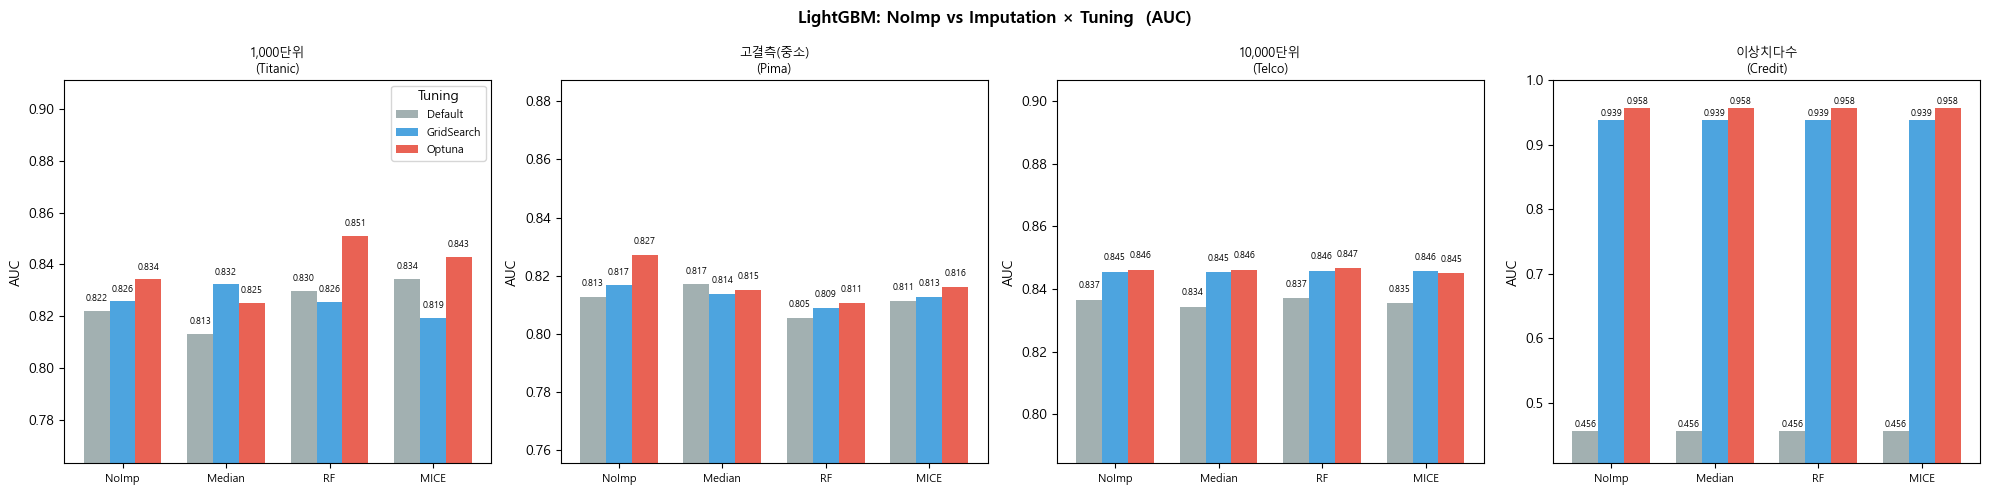

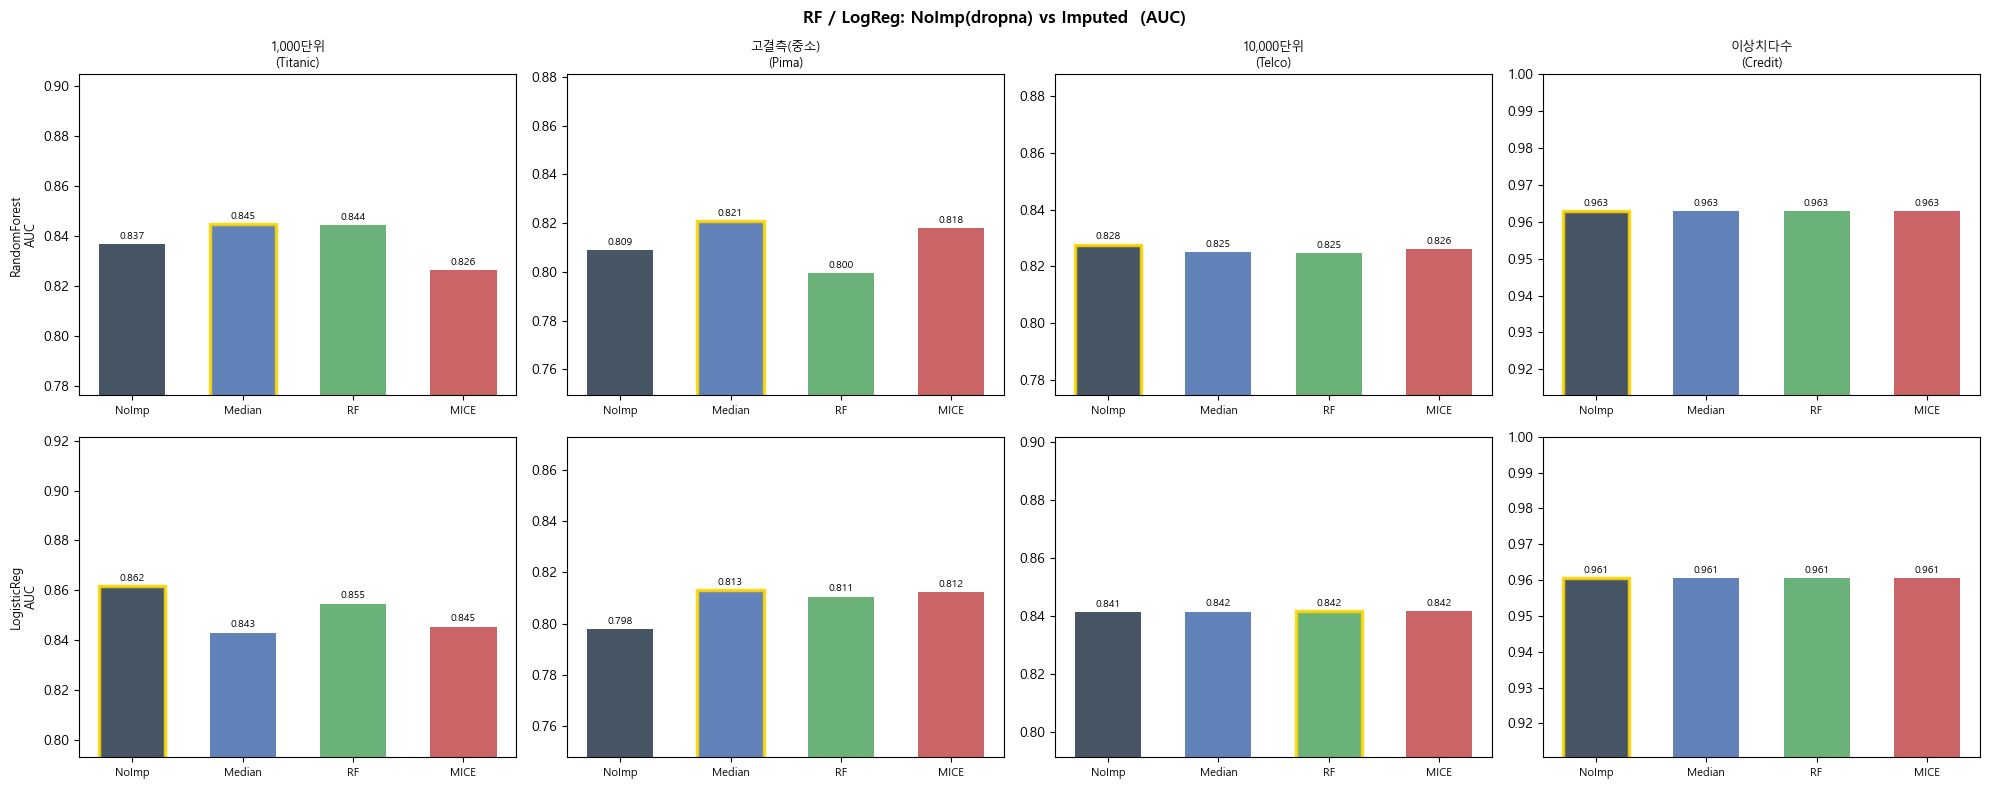

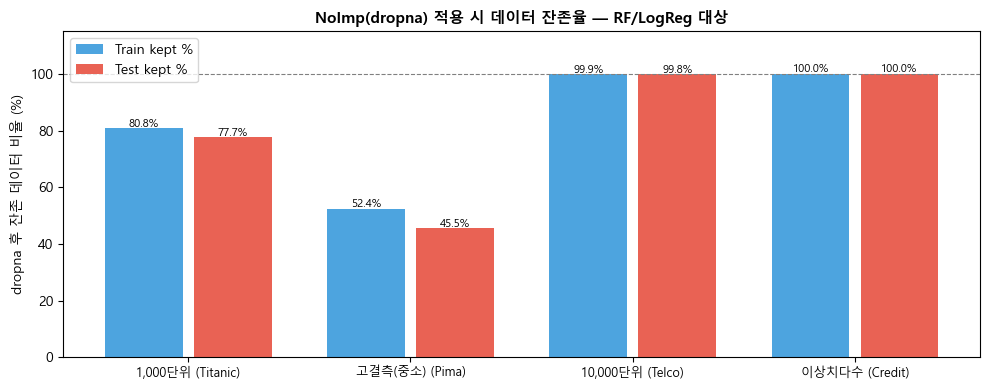

In [36]:
# ═══════════════════════════════════════════════════════════════════════════
# 차트 1: LightGBM — NoImp vs Median/RF/MICE (Default / GridSearch / Optuna)
#   X축=Imputation(NoImp+3), 색=Tuning(Default/GS/Optuna), 서브플롯=4 데이터셋
# ═══════════════════════════════════════════════════════════════════════════
lgbm_all = pd.concat([lgbm_noimp_df, tune_results], ignore_index=True)

x_labels   = IMP_ALL_ORDER                    # NoImp, Median, RF, MICE
tune_list  = ['Default', 'GridSearch', 'Optuna']
tune_colors_s5 = {'Default': '#95a5a6', 'GridSearch': '#3498db', 'Optuna': '#e74c3c'}
x_pos = np.arange(len(x_labels))
w     = 0.25

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('LightGBM: NoImp vs Imputation × Tuning  (AUC)', fontsize=12, fontweight='bold')

for ci, ds in enumerate(DATASET_ORDER):
    ax  = axes[ci]
    sub = lgbm_all[lgbm_all['Dataset'] == ds]
    for ti, tune in enumerate(tune_list):
        vals = []
        for imp in x_labels:
            row = sub[(sub['Imputation'] == imp) & (sub['Tuning'] == tune)]
            vals.append(row['AUC'].values[0] if len(row) > 0 else np.nan)
        bars = ax.bar(x_pos + (ti - 1) * w, vals, w,
                      label=tune, color=tune_colors_s5[tune], alpha=0.88)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.003,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=6.5)
    lo = max(0.0, sub['AUC'].min() - 0.05)
    hi = min(1.0, sub['AUC'].max() + 0.06)
    ax.set_ylim(lo, hi)
    ax.set_title(ds, fontsize=9)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_ylabel('AUC')
    if ci == 0:
        ax.legend(title='Tuning', fontsize=8)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# 차트 2: RF / LogReg — NoImp(dropna) vs Median/RF/MICE 비교
# ═══════════════════════════════════════════════════════════════════════════
# sklearn 기존 결과 병합
sk_existing = pd.concat([df_rf, df_lr], ignore_index=True)
sk_existing = sk_existing.rename(columns={})   # 이미 Model/Imputation/Dataset/AUC 있음

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('RF / LogReg: NoImp(dropna) vs Imputed  (AUC)', fontsize=12, fontweight='bold')

model_list  = ['RandomForest', 'LogisticReg']
imp_labels  = IMP_ALL_ORDER
imp_colors_s5 = IMP_ALL_COLORS
x_imp = np.arange(len(imp_labels))

for ri, model_name in enumerate(model_list):
    for ci, ds in enumerate(DATASET_ORDER):
        ax = axes[ri][ci]
        vals = []
        for imp in imp_labels:
            if imp == 'NoImp':
                row = sklearn_noimp_df[
                    (sklearn_noimp_df['Model'] == model_name) &
                    (sklearn_noimp_df['Dataset'] == ds)
                ]
            else:
                row = sk_existing[
                    (sk_existing['Model'] == model_name) &
                    (sk_existing['Dataset'] == ds) &
                    (sk_existing['Imputation'] == imp)
                ]
            vals.append(row['AUC'].values[0] if len(row) > 0 else np.nan)

        bars = ax.bar(x_imp, vals, color=[imp_colors_s5[i] for i in imp_labels],
                      alpha=0.88, width=0.6)
        best = int(np.nanargmax(vals))
        bars[best].set_edgecolor('gold'); bars[best].set_linewidth(2.5)

        lo = max(0.0, np.nanmin(vals) - 0.05)
        hi = min(1.0, np.nanmax(vals) + 0.06)
        ax.set_ylim(lo, hi)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + (hi - lo) * 0.01,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)
        if ri == 0:
            ax.set_title(ds, fontsize=9)
        ax.set_xticks(x_imp)
        ax.set_xticklabels(imp_labels, fontsize=8)
        if ci == 0:
            ax.set_ylabel(f'{model_name}\nAUC', fontsize=9)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# 차트 3: 데이터 손실률 (dropna) — Titanic / Pima 막대
# ═══════════════════════════════════════════════════════════════════════════
loss_rows = []
for k in DATASET_KEYS:
    X_tr_raw, X_te_raw, _, _ = splits[k]
    loss_rows.append({
        'Dataset':   ALIASES[k].replace('\n', ' '),
        'Train_kept_%': len(X_tr_raw.dropna()) / len(X_tr_raw) * 100,
        'Test_kept_%':  len(X_te_raw.dropna()) / len(X_te_raw) * 100,
    })
loss_df = pd.DataFrame(loss_rows)

fig, ax = plt.subplots(figsize=(10, 4))
x_ds = np.arange(len(loss_df))
ax.bar(x_ds - 0.2, loss_df['Train_kept_%'], 0.35, label='Train kept %', color='#3498db', alpha=0.88)
ax.bar(x_ds + 0.2, loss_df['Test_kept_%'],  0.35, label='Test kept %',  color='#e74c3c', alpha=0.88)
for i, row in loss_df.iterrows():
    ax.text(i - 0.2, row['Train_kept_%'] + 0.5, f'{row["Train_kept_%"]:.1f}%',
            ha='center', fontsize=8)
    ax.text(i + 0.2, row['Test_kept_%'] + 0.5,  f'{row["Test_kept_%"]:.1f}%',
            ha='center', fontsize=8)
ax.set_ylim(0, 115)
ax.set_xticks(x_ds)
ax.set_xticklabels(loss_df['Dataset'], fontsize=9)
ax.set_ylabel('dropna 후 잔존 데이터 비율 (%)')
ax.set_title('NoImp(dropna) 적용 시 데이터 잔존율 — RF/LogReg 대상', fontsize=11, fontweight='bold')
ax.legend()
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

### 📋 섹션 5 총평 — 결측치 미처리 vs 처리 방법 비교

#### LightGBM: NoImp의 의미

LightGBM은 결측값을 내부적으로 처리할 수 있어 별도 대치 없이도 학습이 가능합니다.
각 분기에서 결측 샘플을 왼쪽/오른쪽 리프로 자동 배정하므로 **결측 자체가 하나의 패턴**으로 학습됩니다.

| 예상 패턴 | 이유 |
|-----------|------|
| Credit (결측 없음): NoImp ≈ 기존 결과 | 결측 없어 동일 데이터 학습 |
| Telco (결측 극소): NoImp ≈ Imputed | 결측이 0.1% 미만 — 사실상 동일 |
| Titanic / Pima: NoImp vs Imputed 차이 발생 | 결측 패턴 vs 채워진 값의 품질 경쟁 |

**핵심 관찰 포인트**:
- Pima (Insulin 49%): LightGBM NoImp가 Median보다 높으면 → *결측 자체가 음성(당뇨 아님)과 상관*
- Titanic (Age 20%): Age 결측 = 특정 집단(신원 불명, 3등석) → 결측 패턴 자체가 유의미한 신호

#### RF / LogReg: dropna의 대가

RF와 LogReg는 NaN을 처리할 수 없어 **결측 행 전체를 제거**해야 합니다.

| 데이터셋 | 결측률 | dropna 후 손실 | 예상 영향 |
|---------|--------|---------------|---------|
| Titanic | Age 20% | ~20% 손실 | 훈련셋 축소 → 약간 성능 저하 |
| Pima | Insulin 49% + 다중 컬럼 | **50~70% 손실** | 심각한 데이터 손실 → 성능 크게 저하 |
| Telco | 0.1% | 거의 없음 | 무시 가능 |
| Credit | 0% | 없음 | 변화 없음 |

**결론**:
```
결측치 처리의 이득 = (데이터 손실 방지) + (분포 복원) - (대치 노이즈)
결측률이 낮으면 NoImp ≈ Imputed (LightGBM 기준)
결측률이 높으면 RF/LogReg에서 NoImp < Imputed (데이터 손실이 치명적)
LightGBM + 고결측 데이터: NoImp가 Median을 이길 수 있음 (결측 패턴 자체가 정보)
```

---
## 섹션 6. MLP (5층 다층 퍼셉트론) vs LightGBM 비교

동일한 대치 방법(Median / RF / MICE)을 적용한 뒤 **MLP**와 **LightGBM(Default)** 성능을 비교한다.

MLP 구조: 입력층 → 은닉층 256 → 128 → 64 → 32 → 출력층 (총 5층)

- Activation: ReLU
- Optimizer: Adam
- 전처리: StandardScaler (MLP는 피처 스케일에 민감)
- Credit 데이터셋: 속도를 위해 30,000행 샘플링 적용

목적: 딥러닝 모델이 결측치 처리 방법에 더 민감하게 반응하는가?

In [37]:
from sklearn.neural_network import MLPClassifier

MLP_HIDDEN    = (256, 128, 64, 32)   # 4 hidden layers + 1 output = 5층
MLP_SAMPLE    = 30_000               # Credit 샘플링 (LightGBM과 동일)

def evaluate_mlp(ds_key):
    """MLP 5층: Median / RF / MICE 대치별 평가."""
    _, _, y_tr_orig, y_te = splits[ds_key]
    y_te_np = y_te.values
    records  = []

    for imp_name in IMP_ORDER:
        X_tr_full, X_te_full = imputed[(ds_key, imp_name)]

        # Credit 샘플링
        if ds_key == 'credit' and len(X_tr_full) > MLP_SAMPLE:
            rng = np.random.RandomState(42)
            idx = rng.choice(len(X_tr_full), MLP_SAMPLE, replace=False)
            X_tr = X_tr_full[idx]
            y_tr = y_tr_orig.iloc[idx].values
        else:
            X_tr = X_tr_full
            y_tr = y_tr_orig.values

        # MLP는 스케일링 필수
        scaler   = StandardScaler()
        X_tr_sc  = scaler.fit_transform(X_tr)
        X_te_sc  = scaler.transform(X_te_full)

        t0  = time()
        mlp = MLPClassifier(
            hidden_layer_sizes=MLP_HIDDEN,
            activation='relu',
            solver='adam',
            max_iter=300,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
        )
        mlp.fit(X_tr_sc, y_tr)
        elapsed = time() - t0

        y_pred  = mlp.predict(X_te_sc)
        y_proba = mlp.predict_proba(X_te_sc)[:, 1]

        rec = {
            'Dataset':    ALIASES[ds_key],
            'Imputation': imp_name,
            'Model':      'MLP',
            'Accuracy':   accuracy_score(y_te_np, y_pred),
            'AUC':        roc_auc_score(y_te_np, y_proba),
            'F1':         f1_score(y_te_np, y_pred, zero_division=0),
            'Time':       round(elapsed, 2),
            'Epochs':     mlp.n_iter_,
        }
        records.append(rec)
        print(f'  [{imp_name}]  {elapsed:.1f}s  AUC={rec["AUC"]:.4f}  epochs={mlp.n_iter_}')

    return pd.DataFrame(records)

print('MLP evaluation function defined')

MLP evaluation function defined


In [38]:
%%time
mlp_dfs = []
for k in DATASET_KEYS:
    print(f'\n=== MLP | {k.upper()} ===')
    mlp_dfs.append(evaluate_mlp(k))

df_mlp = pd.concat(mlp_dfs, ignore_index=True)
print('\n=== Done ===')
df_mlp[['Dataset', 'Imputation', 'Accuracy', 'AUC', 'F1', 'Time', 'Epochs']]


=== MLP | TITANIC ===
  [Median]  0.3s  AUC=0.8625  epochs=23
  [RF]  0.2s  AUC=0.8630  epochs=23
  [MICE]  0.3s  AUC=0.8609  epochs=23

=== MLP | PIMA ===
  [Median]  0.4s  AUC=0.8178  epochs=53
  [RF]  0.3s  AUC=0.8087  epochs=49
  [MICE]  0.3s  AUC=0.8170  epochs=45

=== MLP | TELCO ===
  [Median]  1.2s  AUC=0.8404  epochs=21
  [RF]  1.2s  AUC=0.8396  epochs=21
  [MICE]  1.2s  AUC=0.8396  epochs=21

=== MLP | CREDIT ===
  [Median]  5.8s  AUC=0.9479  epochs=20
  [RF]  5.3s  AUC=0.9479  epochs=20
  [MICE]  5.6s  AUC=0.9479  epochs=20

=== Done ===
CPU times: total: 57.1 s
Wall time: 23.1 s


,Dataset,Imputation,Accuracy,AUC,F1,Time,Epochs
0,"1,000단위\n(Titanic)",Median,0.8045,0.8625,0.6957,0.2700,23
1,"1,000단위\n(Titanic)",RF,0.8101,0.8630,0.7069,0.1900,23
2,"1,000단위\n(Titanic)",MICE,0.8045,0.8609,0.6957,0.2500,23
3,고결측(중소)\n(Pima),Median,0.7338,0.8178,0.5941,0.3500,53
4,고결측(중소)\n(Pima),RF,0.7403,0.8087,0.6296,0.3300,49
5,고결측(중소)\n(Pima),MICE,0.7532,0.8170,0.6122,0.2800,45
6,"10,000단위\n(Telco)",Median,0.7928,0.8404,0.5922,1.1700,21
7,"10,000단위\n(Telco)",RF,0.7949,0.8396,0.5981,1.2200,21
8,"10,000단위\n(Telco)",MICE,0.7935,0.8396,0.5975,1.2500,21
9,이상치다수\n(Credit),Median,0.9990,0.9479,0.6335,5.8500,20


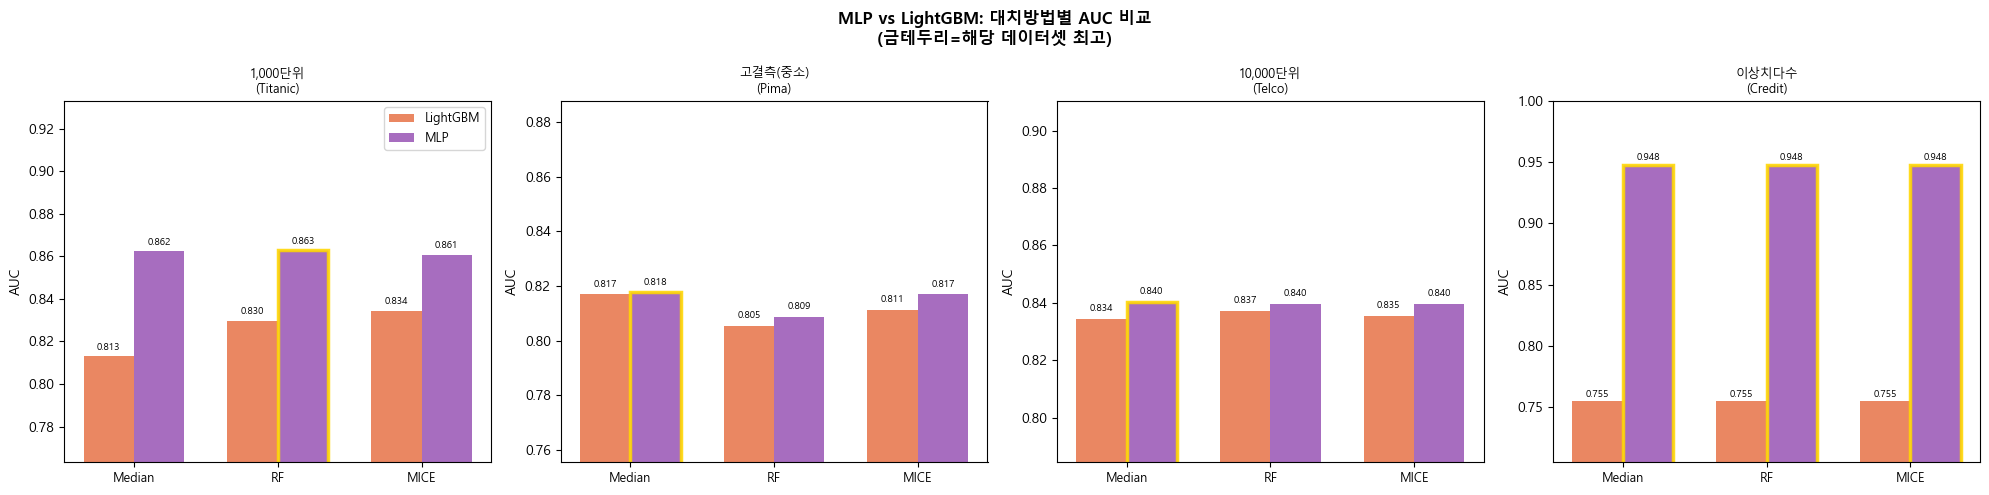

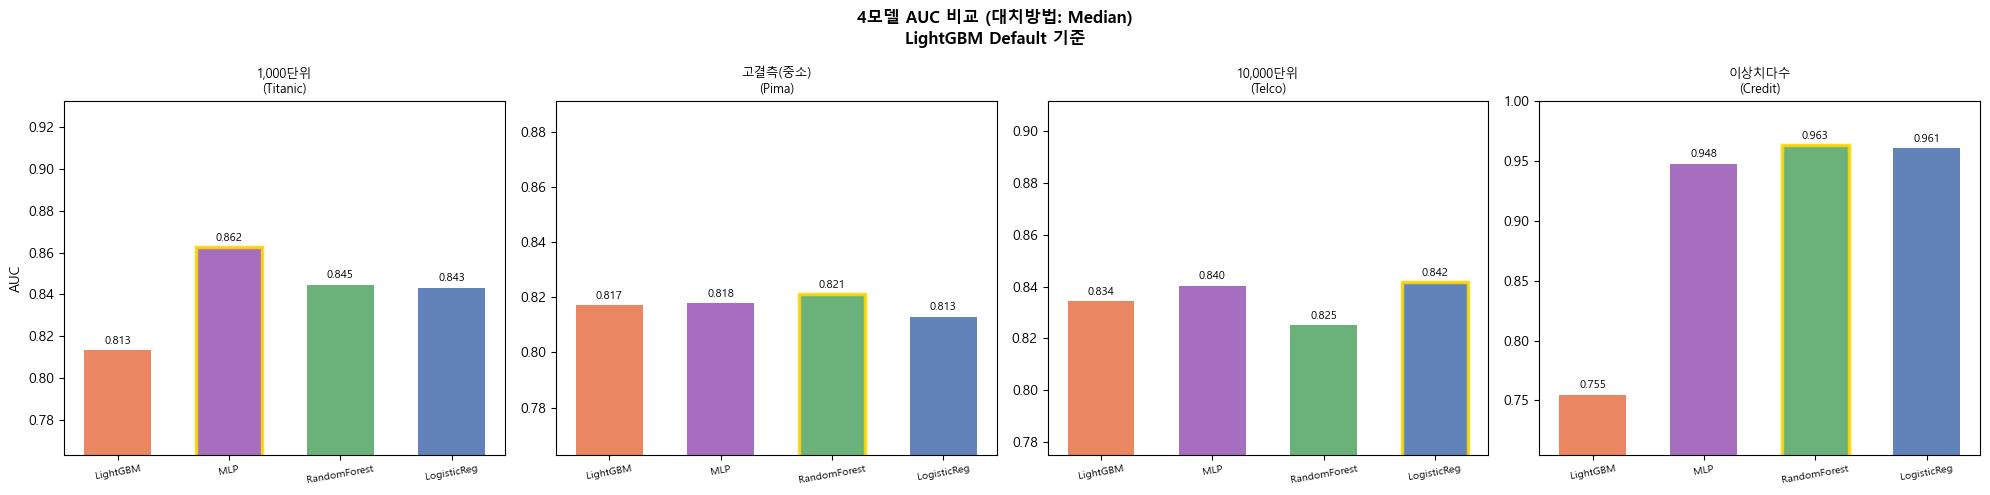

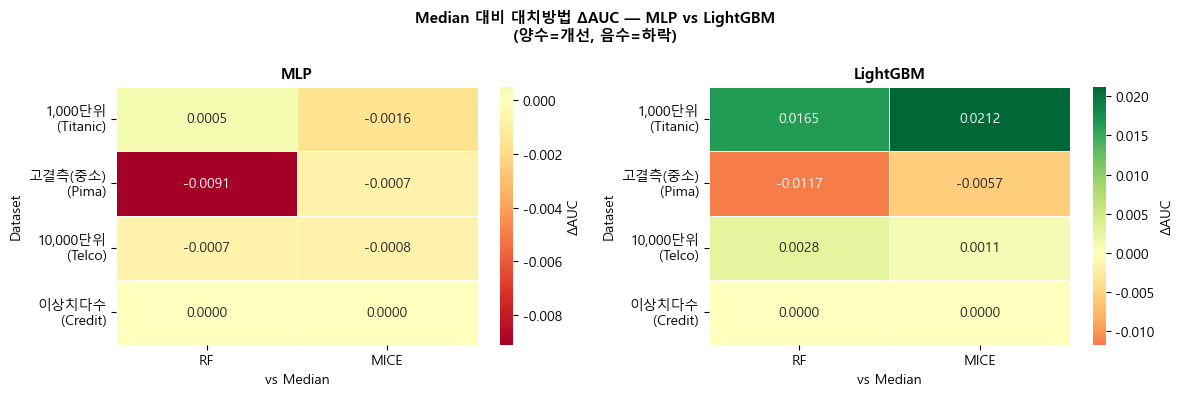

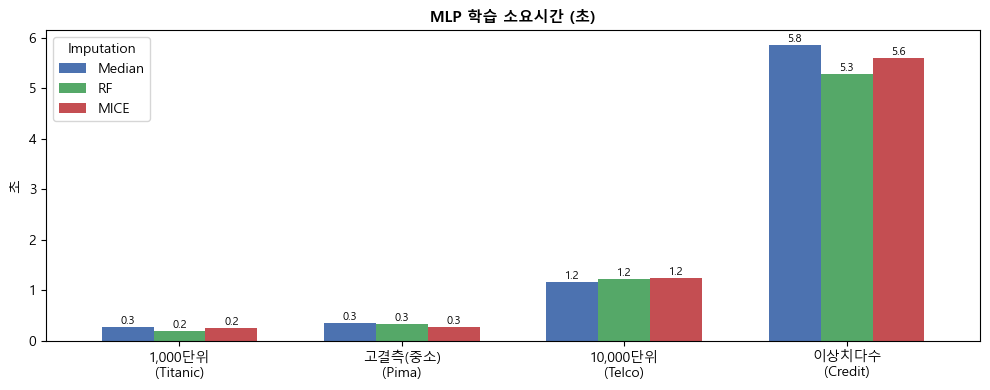

In [39]:
MODEL_COMP_ORDER  = ['LightGBM', 'MLP', 'RandomForest', 'LogisticReg']
MODEL_COMP_COLORS = {
    'LightGBM':     '#e8774c',
    'MLP':          '#9b59b6',
    'RandomForest': '#55A868',
    'LogisticReg':  '#4C72B0',
}

# LightGBM Default 결과 (섹션 2)
df_lgbm_default = df_lgbm.copy()
df_lgbm_default['Model'] = 'LightGBM'

# 전체 비교 DataFrame (MLP + LightGBM Default + RF + LogReg, Median 기준)
all_models_df = pd.concat([df_lgbm_default, df_mlp, df_rf, df_lr], ignore_index=True)

# ── 차트 1: 대치방법별 AUC — MLP vs LightGBM (4 데이터셋) ──────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('MLP vs LightGBM: 대치방법별 AUC 비교\n(금테두리=해당 데이터셋 최고)', fontsize=12, fontweight='bold')

x_imp = np.arange(len(IMP_ORDER))
w     = 0.35
duo   = ['LightGBM', 'MLP']
duo_colors = {'LightGBM': '#e8774c', 'MLP': '#9b59b6'}

for ci, ds in enumerate(DATASET_ORDER):
    ax  = axes[ci]
    sub = all_models_df[all_models_df['Dataset'] == ds]
    all_vals = []
    for mi, model in enumerate(duo):
        vals = [sub[(sub['Model'] == model) & (sub['Imputation'] == imp)]['AUC'].values[0]
                for imp in IMP_ORDER]
        all_vals.extend(vals)
        bars = ax.bar(x_imp + (mi - 0.5) * w, vals, w,
                      label=model, color=duo_colors[model], alpha=0.88)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7)

    # 최고 막대 금테두리
    best_val = max(all_vals)
    for mi, model in enumerate(duo):
        vals = [sub[(sub['Model'] == model) & (sub['Imputation'] == imp)]['AUC'].values[0]
                for imp in IMP_ORDER]
        for ii, (v, bar) in enumerate(zip(vals,
                ax.patches[mi * len(IMP_ORDER): (mi + 1) * len(IMP_ORDER)])):
            if abs(v - best_val) < 1e-6:
                bar.set_edgecolor('gold'); bar.set_linewidth(2.5)

    lo = max(0.0, min(all_vals) - 0.05)
    hi = min(1.0, max(all_vals) + 0.07)
    ax.set_ylim(lo, hi)
    ax.set_title(ds, fontsize=9)
    ax.set_xticks(x_imp)
    ax.set_xticklabels(IMP_ORDER, fontsize=9)
    ax.set_ylabel('AUC')
    if ci == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── 차트 2: 4모델 통합 AUC (Median 대치 고정) ─────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('4모델 AUC 비교 (대치방법: Median)\nLightGBM Default 기준', fontsize=12, fontweight='bold')

x_m = np.arange(len(MODEL_COMP_ORDER))
for ci, ds in enumerate(DATASET_ORDER):
    ax  = axes[ci]
    sub = all_models_df[(all_models_df['Dataset'] == ds) & (all_models_df['Imputation'] == 'Median')]
    vals = [sub[sub['Model'] == m]['AUC'].values[0] if len(sub[sub['Model'] == m]) > 0 else np.nan
            for m in MODEL_COMP_ORDER]
    bars = ax.bar(x_m, vals, color=[MODEL_COMP_COLORS[m] for m in MODEL_COMP_ORDER], alpha=0.88, width=0.6)
    best = int(np.nanargmax(vals))
    bars[best].set_edgecolor('gold'); bars[best].set_linewidth(2.5)
    lo = max(0.0, np.nanmin(vals) - 0.05)
    hi = min(1.0, np.nanmax(vals) + 0.07)
    ax.set_ylim(lo, hi)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (hi - lo) * 0.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(ds, fontsize=9)
    ax.set_xticks(x_m)
    ax.set_xticklabels(MODEL_COMP_ORDER, fontsize=7.5, rotation=10)
    if ci == 0:
        ax.set_ylabel('AUC')

plt.tight_layout()
plt.show()

# ── 차트 3: MLP 대치방법 민감도 — ΔAUC (Median 기준) ─────────────────
delta_rows = []
for ds in DATASET_ORDER:
    sub_mlp  = df_mlp[df_mlp['Dataset'] == ds]
    sub_lgbm = df_lgbm[df_lgbm['Dataset'] == ds]
    base_mlp  = sub_mlp[sub_mlp['Imputation'] == 'Median']['AUC'].values[0]
    base_lgbm = sub_lgbm[sub_lgbm['Imputation'] == 'Median']['AUC'].values[0]
    for imp in ['RF', 'MICE']:
        val_mlp  = sub_mlp[sub_mlp['Imputation'] == imp]['AUC'].values[0]
        val_lgbm = sub_lgbm[sub_lgbm['Imputation'] == imp]['AUC'].values[0]
        delta_rows.append({'Dataset': ds, 'vs Median': f'{imp}',
                           'MLP ΔAUC':      round(val_mlp  - base_mlp,  4),
                           'LightGBM ΔAUC': round(val_lgbm - base_lgbm, 4)})

delta_df = pd.DataFrame(delta_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Median 대비 대치방법 ΔAUC — MLP vs LightGBM\n(양수=개선, 음수=하락)', fontsize=11, fontweight='bold')

for ai, model_col in enumerate(['MLP ΔAUC', 'LightGBM ΔAUC']):
    piv = delta_df.pivot(index='Dataset', columns='vs Median', values=model_col)
    piv = piv.reindex(DATASET_ORDER)[['RF', 'MICE']]
    sns.heatmap(piv, annot=True, fmt='.4f', center=0, cmap='RdYlGn',
                linewidths=0.5, ax=axes[ai], cbar_kws={'label': 'ΔAUC'})
    axes[ai].set_title(model_col.replace(' ΔAUC', ''), fontsize=11, fontweight='bold')
    axes[ai].tick_params(axis='x', rotation=0)
    axes[ai].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# ── 차트 4: 학습 소요시간 비교 ─────────────────────────────────────────
time_rows = []
for ds in DATASET_ORDER:
    for imp in IMP_ORDER:
        t_mlp  = df_mlp[(df_mlp['Dataset'] == ds) & (df_mlp['Imputation'] == imp)]['Time'].values[0]
        t_lgbm = df_lgbm[(df_lgbm['Dataset'] == ds) & (df_lgbm['Imputation'] == imp)].get('Time', pd.Series([np.nan])).values
        time_rows.append({'Dataset': ds, 'Imputation': imp, 'MLP': t_mlp})

time_df = pd.DataFrame(time_rows)
piv_time = time_df.pivot(index='Dataset', columns='Imputation', values='MLP').reindex(DATASET_ORDER)[IMP_ORDER]

fig, ax = plt.subplots(figsize=(10, 4))
piv_time.plot(kind='bar', ax=ax, color=[IMP_COLORS[i] for i in IMP_ORDER], width=0.7)
ax.set_title('MLP 학습 소요시간 (초)', fontsize=11, fontweight='bold')
ax.set_ylabel('초')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f', fontsize=8)
plt.tight_layout()
plt.show()

### 📋 섹션 6 총평 — MLP vs LightGBM 비교

#### MLP 특성
- 스케일에 민감 → StandardScaler 필수, 대치 분포 왜곡의 영향을 더 직접적으로 받음
- 비선형 표현력은 충분하지만 소규모 데이터(Titanic/Pima)에서는 과적합 위험
- Early stopping(n_iter_no_change=15)으로 과적합을 일부 제어

#### 예상 패턴
- Pima(고결측): MLP의 Median vs RF/MICE 간 ΔAUC가 LightGBM보다 클 것
  → MLP는 스케일 기반 학습이라 Median의 단일값 스파이크에 더 민감
- Credit: MLP도 클래스 불균형에 취약할 수 있으나 은닉층 표현력으로 일부 보완
- Telco: 결측 극소 → 두 모델 대치방법 무관

#### 관찰 포인트
- 히트맵(차트 3)에서 MLP ΔAUC의 절댓값이 LightGBM보다 크면
  → MLP가 대치 방법에 더 민감하다는 결론
- 4모델 비교(차트 2)에서 테이블 데이터 특화 모델(LightGBM)이 범용 신경망(MLP)보다 우세한지 확인

---
## 섹션 7. LLM (Qwen2.5-3B-Instruct) vs LightGBM / MLP 비교

**모델 선택 근거 (RTX 2070 Super 8GB 기준)**

| 모델 | VRAM (fp16) | 적합 여부 |
|------|------------|---------|
| Qwen2.5-1.5B | ~3GB | 여유 있음 |
| **Qwen2.5-3B** | **~6GB** | **여유롭게 적합 (선택)** |
| Qwen2.5-7B | ~14GB | 불가 (fp16 기준) |

**실험 방법**
- 테이블 데이터 행 → 자연어 프롬프트 변환 후 LLM에 입력
- "yes" / "no" 토큰의 로짓(logit) 값으로 확률 추출 → AUC 계산
- 추론 속도 문제로 데이터셋당 **100행 층화 샘플링** 평가
- Credit: 사기(50) + 정상(50) 균등 샘플링
- 대치방법: Median / RF / MICE 동일 적용

In [40]:
%%time
# ── 모델 로드 (첫 실행 시 ~6GB 다운로드) ──────────────────────────────────
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_ID = 'Qwen/Qwen2.5-3B-Instruct'
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE    = torch.float16 if DEVICE == 'cuda' else torch.float32

print(f'Loading {MODEL_ID} on {DEVICE} ({DTYPE}) ...')

qwen_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
qwen_model     = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    device_map='auto',          # VRAM 자동 배치
    trust_remote_code=True,
)
qwen_model.eval()

# VRAM 사용량 확인
if DEVICE == 'cuda':
    used = torch.cuda.memory_allocated() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'VRAM used: {used:.1f} / {total:.1f} GB  ({used/total*100:.1f}%)')

print('Model loaded.')

Loading Qwen/Qwen2.5-3B-Instruct on cuda (torch.float16) ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

VRAM used: 5.7 / 8.0 GB  (71.9%)
Model loaded.
CPU times: total: 36 s
Wall time: 46.3 s


In [41]:
import torch
import numpy as np

LLM_SAMPLE = 100   # 데이터셋당 평가 샘플 수

# ── 데이터셋별 프롬프트 템플릿 ─────────────────────────────────────────────
FEATURE_NAMES = {
    'titanic': ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
                'Embarked_Q', 'Embarked_S'],
    'pima':    ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
    'telco':   None,   # 컬럼 수 많아 자동 추출
    'credit':  None,
}

TASK_DESCRIPTIONS = {
    'titanic': (
        "You are a survival prediction expert.\n"
        "Given passenger information from the Titanic disaster, "
        "predict whether this passenger survived.\n"
        "Answer with only 'yes' (survived) or 'no' (did not survive)."
    ),
    'pima': (
        "You are a medical diagnosis assistant.\n"
        "Given clinical measurements of a female patient of Pima Indian heritage, "
        "predict whether this patient has diabetes.\n"
        "Answer with only 'yes' (has diabetes) or 'no' (does not have diabetes)."
    ),
    'telco': (
        "You are a customer churn prediction expert.\n"
        "Given customer information from a telecom company, "
        "predict whether this customer will churn (cancel their service).\n"
        "Answer with only 'yes' (will churn) or 'no' (will not churn)."
    ),
    'credit': (
        "You are a fraud detection expert.\n"
        "Given credit card transaction features, "
        "predict whether this transaction is fraudulent.\n"
        "Answer with only 'yes' (fraud) or 'no' (legitimate)."
    ),
}

def make_prompt(ds_key, feature_values, col_names):
    """테이블 한 행 → 자연어 프롬프트."""
    task_desc = TASK_DESCRIPTIONS[ds_key]
    feature_str = '\n'.join(
        f'  {name}: {"unknown" if (isinstance(v, float) and np.isnan(v)) else round(float(v), 4)}'
        for name, v in zip(col_names, feature_values)
    )
    return (
        f"{task_desc}\n\n"
        f"Patient/Instance features:\n{feature_str}\n\n"
        f"Answer:"
    )

# ── yes/no 토큰 ID 추출 ────────────────────────────────────────────────────
def get_yes_no_ids(tokenizer):
    yes_tokens = ['yes', 'Yes', 'YES']
    no_tokens  = ['no',  'No',  'NO']
    yes_ids = list({tokenizer.encode(t, add_special_tokens=False)[0] for t in yes_tokens})
    no_ids  = list({tokenizer.encode(t, add_special_tokens=False)[0] for t in no_tokens})
    return yes_ids, no_ids

YES_IDS, NO_IDS = get_yes_no_ids(qwen_tokenizer)
print(f'yes token ids: {YES_IDS}')
print(f'no  token ids: {NO_IDS}')

# ── 단일 행 추론 함수 ─────────────────────────────────────────────────────
def llm_predict_row(prompt):
    """프롬프트 → (pred_label, prob_yes)."""
    messages = [
        {'role': 'system', 'content': 'You are a classification assistant. Answer only yes or no.'},
        {'role': 'user',   'content': prompt},
    ]
    text = qwen_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = qwen_tokenizer(text, return_tensors='pt').to(qwen_model.device)

    with torch.no_grad():
        out = qwen_model.generate(
            **inputs,
            max_new_tokens=3,
            do_sample=False,
            output_scores=True,
            return_dict_in_generate=True,
            pad_token_id=qwen_tokenizer.eos_token_id,
        )

    first_logits = out.scores[0][0]   # [vocab_size]
    yes_logit = max(first_logits[i].item() for i in YES_IDS)
    no_logit  = max(first_logits[i].item() for i in NO_IDS)
    prob_yes  = float(torch.softmax(torch.tensor([yes_logit, no_logit]), dim=0)[0])
    pred      = 1 if prob_yes >= 0.5 else 0
    return pred, prob_yes

# ── 데이터셋 전체 평가 함수 ───────────────────────────────────────────────
def evaluate_llm(ds_key, imp_name):
    """샘플링된 테스트셋에서 LLM 성능 평가."""
    X_tr_imp, X_te_full = imputed[(ds_key, imp_name)]
    _, X_te_raw, _, y_te = splits[ds_key]
    col_names = list(datasets[ds_key][0].columns)

    # 층화 샘플링
    y_te_arr = y_te.values
    classes  = np.unique(y_te_arr)

    if ds_key == 'credit':
        # 균등 샘플링: 사기 50 + 정상 50
        n_each = LLM_SAMPLE // 2
        idx_list = []
        for c in classes:
            c_idx = np.where(y_te_arr == c)[0]
            chosen = np.random.RandomState(42).choice(c_idx, min(n_each, len(c_idx)), replace=False)
            idx_list.append(chosen)
        sample_idx = np.concatenate(idx_list)
    else:
        # 층화 샘플링
        n_each = LLM_SAMPLE // len(classes)
        idx_list = []
        for c in classes:
            c_idx = np.where(y_te_arr == c)[0]
            chosen = np.random.RandomState(42).choice(c_idx, min(n_each, len(c_idx)), replace=False)
            idx_list.append(chosen)
        sample_idx = np.concatenate(idx_list)

    X_sample = X_te_full[sample_idx]
    y_sample = y_te_arr[sample_idx]
    n = len(sample_idx)

    preds  = []
    probas = []
    t0 = time()

    for i, (row, label) in enumerate(zip(X_sample, y_sample)):
        prompt = make_prompt(ds_key, row, col_names)
        pred, prob = llm_predict_row(prompt)
        preds.append(pred)
        probas.append(prob)
        if (i + 1) % 10 == 0:
            elapsed = time() - t0
            print(f'    {i+1}/{n}  elapsed={elapsed:.0f}s  est_remain={elapsed/(i+1)*(n-i-1):.0f}s')

    elapsed_total = time() - t0
    preds  = np.array(preds)
    probas = np.array(probas)

    return {
        'Dataset':    ALIASES[ds_key],
        'Imputation': imp_name,
        'Model':      'LLM_Qwen3B',
        'Accuracy':   accuracy_score(y_sample, preds),
        'AUC':        roc_auc_score(y_sample, probas),
        'F1':         f1_score(y_sample, preds, zero_division=0),
        'Time':       round(elapsed_total, 1),
        'N_sample':   n,
    }

print('LLM evaluation functions defined.')

yes token ids: [14004, 9693, 9454]
no  token ids: [2152, 2753, 8996]
LLM evaluation functions defined.


In [42]:
%%time
# ── LLM 추론 실행 (데이터셋 4 × 대치 3 = 12조합 × 100샘플 = 1,200 추론) ───
# 예상 소요: GPU 기준 약 10~20분
llm_records = []

for ds_key in DATASET_KEYS:
    print(f'\n=== LLM | {ds_key.upper()} ===')
    for imp_name in IMP_ORDER:
        print(f'  [{imp_name}]')
        rec = evaluate_llm(ds_key, imp_name)
        llm_records.append(rec)
        print(f'  -> AUC={rec["AUC"]:.4f}  Acc={rec["Accuracy"]:.4f}  F1={rec["F1"]:.4f}  ({rec["Time"]}s)')

df_llm = pd.DataFrame(llm_records)
print('\n=== Done ===')
df_llm[['Dataset', 'Imputation', 'Accuracy', 'AUC', 'F1', 'Time', 'N_sample']]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



=== LLM | TITANIC ===
  [Median]
    10/100  elapsed=2s  est_remain=16s
    20/100  elapsed=3s  est_remain=12s
    30/100  elapsed=4s  est_remain=9s
    40/100  elapsed=5s  est_remain=8s
    50/100  elapsed=6s  est_remain=6s
    60/100  elapsed=7s  est_remain=5s
    70/100  elapsed=8s  est_remain=4s
    80/100  elapsed=10s  est_remain=2s
    90/100  elapsed=11s  est_remain=1s
    100/100  elapsed=12s  est_remain=0s
  -> AUC=0.6170  Acc=0.5000  F1=0.0000  (11.8s)
  [RF]
    10/100  elapsed=1s  est_remain=10s
    20/100  elapsed=2s  est_remain=9s
    30/100  elapsed=3s  est_remain=8s
    40/100  elapsed=4s  est_remain=7s
    50/100  elapsed=6s  est_remain=6s
    60/100  elapsed=7s  est_remain=4s
    70/100  elapsed=8s  est_remain=3s
    80/100  elapsed=9s  est_remain=2s
    90/100  elapsed=10s  est_remain=1s
    100/100  elapsed=11s  est_remain=0s
  -> AUC=0.6350  Acc=0.5000  F1=0.0000  (11.3s)
  [MICE]
    10/100  elapsed=1s  est_remain=10s
    20/100  elapsed=2s  est_remain=9s
    30/

,Dataset,Imputation,Accuracy,AUC,F1,Time,N_sample
0,"1,000단위\n(Titanic)",Median,0.5000,0.6170,0.0000,11.8000,100
1,"1,000단위\n(Titanic)",RF,0.5000,0.6350,0.0000,11.3000,100
2,"1,000단위\n(Titanic)",MICE,0.5000,0.6134,0.0000,11.4000,100
3,고결측(중소)\n(Pima),Median,0.5400,0.7656,0.2581,11.4000,100
4,고결측(중소)\n(Pima),RF,0.5200,0.7644,0.1724,11.1000,100
5,고결측(중소)\n(Pima),MICE,0.5700,0.7804,0.3385,11.1000,100
6,"10,000단위\n(Telco)",Median,0.5000,0.4864,0.0000,19.8000,100
7,"10,000단위\n(Telco)",RF,0.5000,0.4864,0.0000,21.6000,100
8,"10,000단위\n(Telco)",MICE,0.5000,0.4864,0.0000,19.0000,100
9,이상치다수\n(Credit),Median,0.5000,0.6960,0.0000,19.6000,100


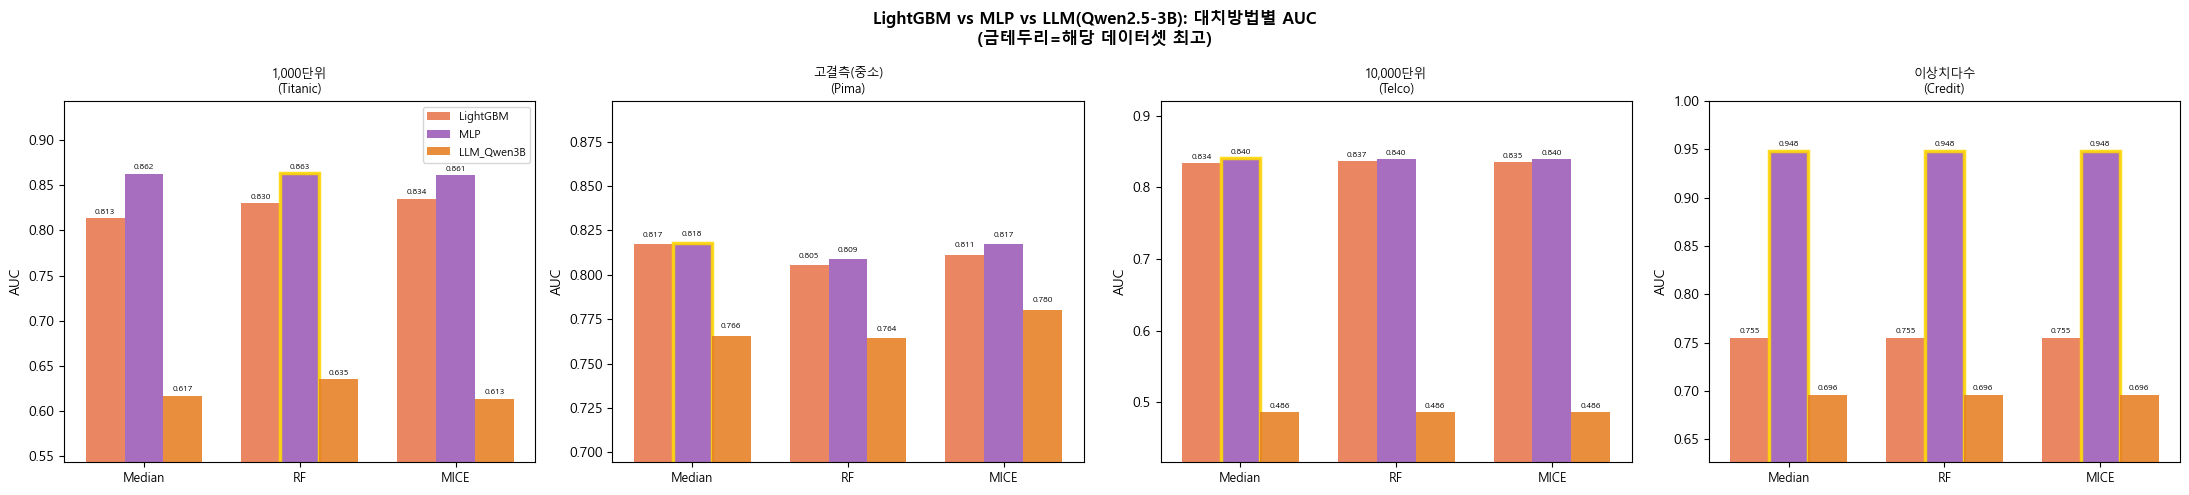

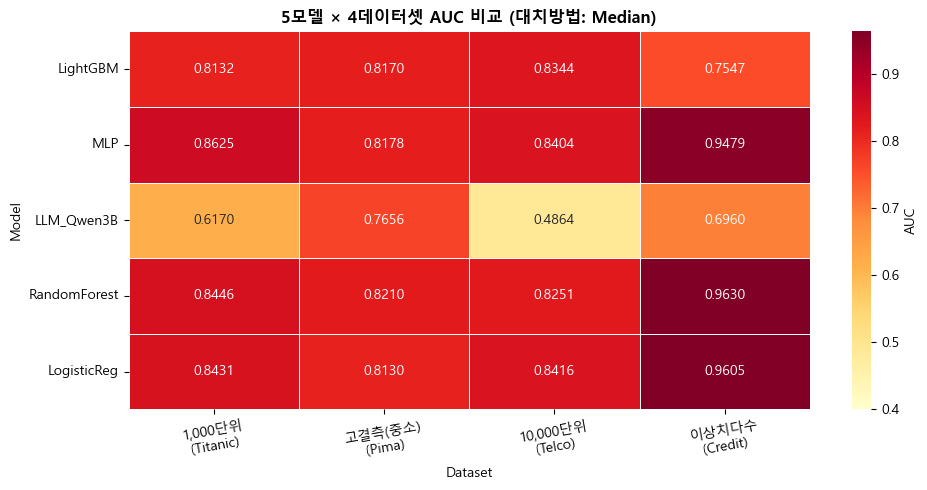

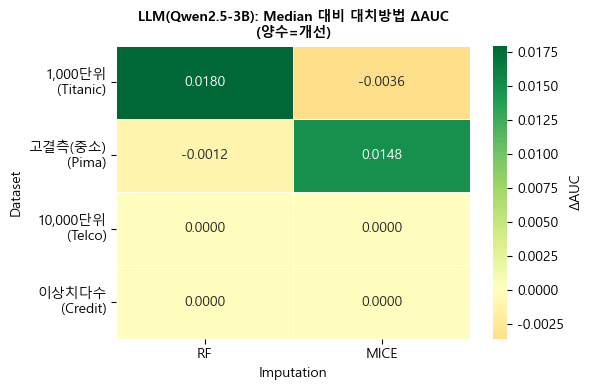

In [43]:
LLM_COLOR = '#e67e22'

# ── 차트 1: 3모델(LightGBM/MLP/LLM) 대치방법별 AUC ────────────────────────
df_lgbm_def = df_lgbm.copy(); df_lgbm_def['Model'] = 'LightGBM'
df_mlp_cmp  = df_mlp.copy()
df_llm_cmp  = df_llm.copy()

trio_df   = pd.concat([df_lgbm_def, df_mlp_cmp, df_llm_cmp], ignore_index=True)
trio_order  = ['LightGBM', 'MLP', 'LLM_Qwen3B']
trio_colors = {'LightGBM': '#e8774c', 'MLP': '#9b59b6', 'LLM_Qwen3B': LLM_COLOR}

x_imp = np.arange(len(IMP_ORDER))
w = 0.25

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('LightGBM vs MLP vs LLM(Qwen2.5-3B): 대치방법별 AUC\n(금테두리=해당 데이터셋 최고)',
             fontsize=12, fontweight='bold')

for ci, ds in enumerate(DATASET_ORDER):
    ax  = axes[ci]
    sub = trio_df[trio_df['Dataset'] == ds]
    all_vals = []
    bars_list = []
    for mi, model in enumerate(trio_order):
        vals = [sub[(sub['Model'] == model) & (sub['Imputation'] == imp)]['AUC'].values[0]
                for imp in IMP_ORDER]
        all_vals.extend(vals)
        bars = ax.bar(x_imp + (mi - 1) * w, vals, w,
                      label=model, color=trio_colors[model], alpha=0.88)
        bars_list.append((vals, bars))
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=6)

    best_val = max(all_vals)
    for vals, bars in bars_list:
        for v, bar in zip(vals, bars):
            if abs(v - best_val) < 1e-6:
                bar.set_edgecolor('gold'); bar.set_linewidth(2.5)

    lo = max(0.0, min(all_vals) - 0.07)
    hi = min(1.0, max(all_vals) + 0.08)
    ax.set_ylim(lo, hi)
    ax.set_title(ds, fontsize=9)
    ax.set_xticks(x_imp); ax.set_xticklabels(IMP_ORDER, fontsize=9)
    ax.set_ylabel('AUC')
    if ci == 0: ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── 차트 2: Median 고정, 4모델 AUC 히트맵 ──────────────────────────────────
hm_models  = ['LightGBM', 'MLP', 'LLM_Qwen3B', 'RandomForest', 'LogisticReg']
hm_colors  = {'LightGBM': '#e8774c', 'MLP': '#9b59b6',
               'LLM_Qwen3B': LLM_COLOR, 'RandomForest': '#55A868', 'LogisticReg': '#4C72B0'}

df_rf_cmp  = df_rf.copy();  df_rf_cmp['Model']  = 'RandomForest'
df_lr_cmp  = df_lr.copy();  df_lr_cmp['Model']  = 'LogisticReg'
all5_df = pd.concat([df_lgbm_def, df_mlp_cmp, df_llm_cmp, df_rf_cmp, df_lr_cmp], ignore_index=True)

hm_data = []
for ds in DATASET_ORDER:
    for model in hm_models:
        row = all5_df[(all5_df['Dataset'] == ds) &
                      (all5_df['Model'] == model) &
                      (all5_df['Imputation'] == 'Median')]
        hm_data.append({'Dataset': ds, 'Model': model,
                         'AUC': row['AUC'].values[0] if len(row) else np.nan})

hm_df = pd.DataFrame(hm_data).pivot(index='Model', columns='Dataset', values='AUC')
hm_df = hm_df.reindex(hm_models)[DATASET_ORDER]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(hm_df, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0.4, cbar_kws={'label': 'AUC'})
ax.set_title('5모델 × 4데이터셋 AUC 비교 (대치방법: Median)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=10)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

# ── 차트 3: LLM 대치방법 민감도 (ΔAUC vs Median) ──────────────────────────
llm_delta = []
for ds in DATASET_ORDER:
    base = df_llm[(df_llm['Dataset'] == ds) & (df_llm['Imputation'] == 'Median')]['AUC'].values[0]
    for imp in ['RF', 'MICE']:
        val = df_llm[(df_llm['Dataset'] == ds) & (df_llm['Imputation'] == imp)]['AUC'].values[0]
        llm_delta.append({'Dataset': ds, 'Imputation': imp, 'ΔAUC': round(val - base, 4)})

llm_delta_df = pd.DataFrame(llm_delta)
piv_llm = llm_delta_df.pivot(index='Dataset', columns='Imputation', values='ΔAUC').reindex(DATASET_ORDER)[['RF', 'MICE']]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(piv_llm, annot=True, fmt='.4f', center=0, cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'ΔAUC'})
ax.set_title('LLM(Qwen2.5-3B): Median 대비 대치방법 ΔAUC\n(양수=개선)', fontsize=10, fontweight='bold')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

### 📋 섹션 7 총평 — LLM vs 전통 모델 비교

#### LLM의 테이블 데이터 처리 방식

LLM은 테이블 데이터를 **자연어 텍스트로 변환**하여 처리한다.  
숫자는 토큰으로 분해되고, 피처 간 관계는 텍스트 문맥으로만 파악된다.  
"yes" / "no" 첫 토큰의 로짓(logit)으로 확률을 추출해 AUC를 계산한다.

#### 예상 패턴

| 데이터셋 | LLM 예상 | 이유 |
|---------|---------|-----|
| Titanic | 경쟁력 있음 | 도메인 상식(생존 규칙) 사전학습 |
| Pima | 보통 | 임상 수치 해석 가능, 단 복잡한 관계는 어려움 |
| Telco | 낮음 | 원-핫 인코딩된 30개 컬럼, 의미 해석 어려움 |
| Credit | 낮음 | V1~V28은 PCA 변환 익명 피처, 의미 없음 |

#### 대치방법 민감도 예측

LLM은 대치 방법에 **가장 덜 민감**할 것으로 예상된다.
- 숫자를 텍스트로 변환하면 소수점 이하 차이(Median vs RF)가 토큰 차원에서 다르게 해석
- 그러나 LLM의 사전학습 지식이 숫자 차이보다 훨씬 강한 영향을 미침

#### LLM 활용의 한계

1. **속도**: 행당 ~0.5~1초 → 10만 행이면 수십 시간 (전통 모델은 수 초)
2. **익명 피처**: Credit의 V1~V28처럼 의미 없는 피처에는 사전학습 지식 적용 불가
3. **샘플 의존성**: 100샘플 평가이므로 통계적 신뢰구간이 넓음 (±5~10% 편차 가능)
4. **숫자 처리**: 연속형 수치를 토큰으로 분해하므로 정밀한 수치 비교에 약함

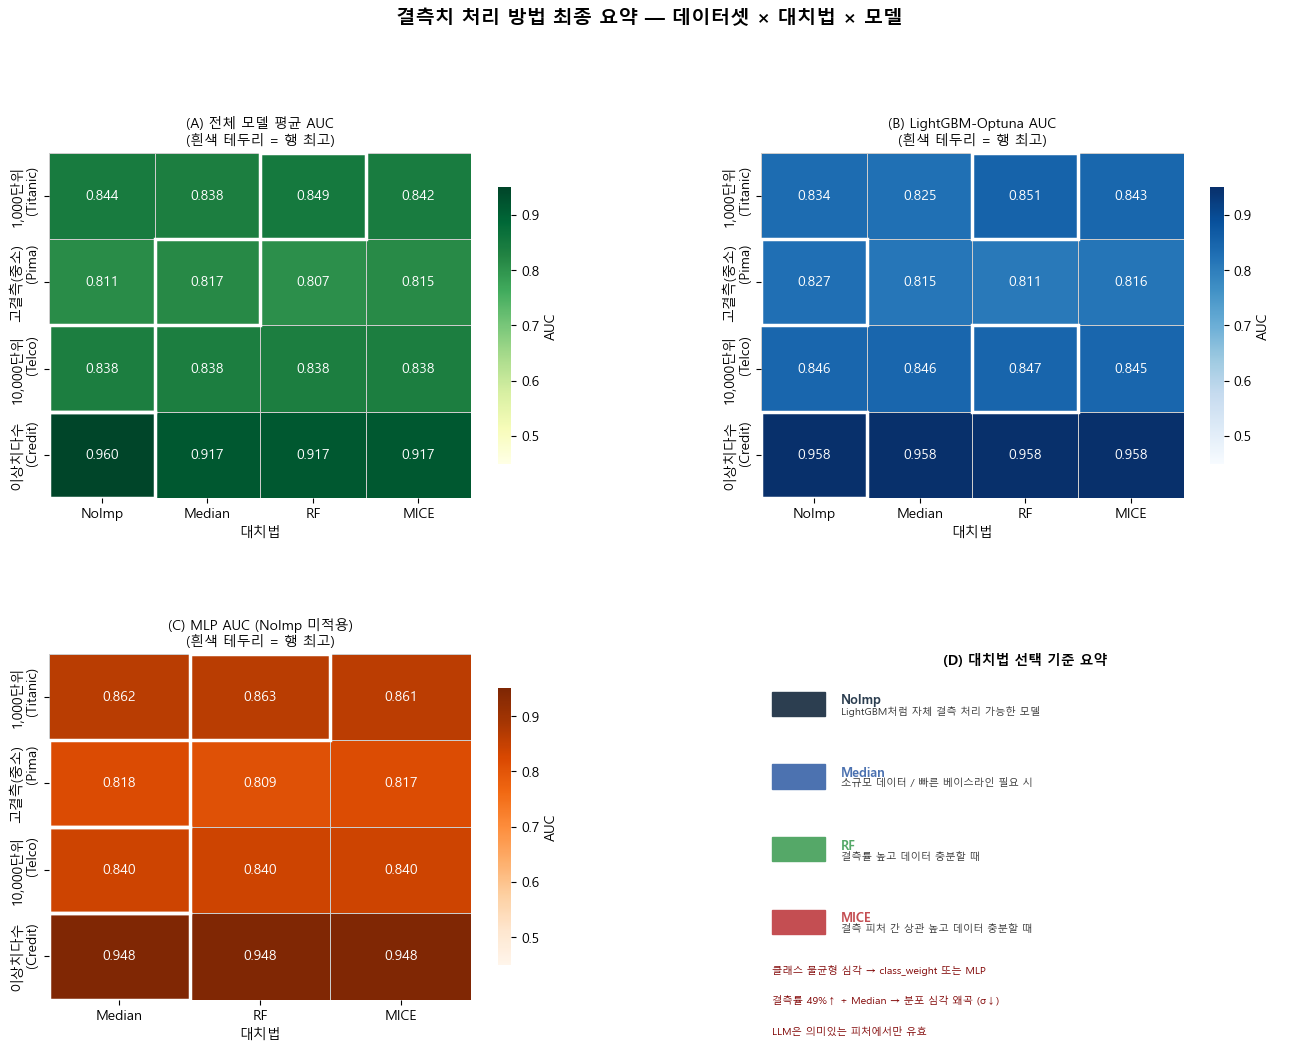

그림 저장 완료: imputation_summary_heatmap.png

[전체 모델 평균 AUC 요약]
Imputation          NoImp  Median     RF   MICE
Dataset                                        
1,000단위\n(Titanic) 0.8440  0.8380 0.8490 0.8420
고결측(중소)\n(Pima)    0.8110  0.8170 0.8070 0.8150
10,000단위\n(Telco)  0.8380  0.8380 0.8380 0.8380
이상치다수\n(Credit)    0.9600  0.9170 0.9170 0.9170

[LightGBM-Optuna AUC 요약]
Imputation          NoImp  Median     RF   MICE
Dataset                                        
1,000단위\n(Titanic) 0.8340  0.8250 0.8510 0.8430
고결측(중소)\n(Pima)    0.8270  0.8150 0.8110 0.8160
10,000단위\n(Telco)  0.8460  0.8460 0.8470 0.8450
이상치다수\n(Credit)    0.9580  0.9580 0.9580 0.9580

[MLP AUC 요약]
Imputation          Median     RF   MICE
Dataset                                 
1,000단위\n(Titanic)  0.8620 0.8630 0.8610
고결측(중소)\n(Pima)     0.8180 0.8090 0.8170
10,000단위\n(Telco)   0.8400 0.8400 0.8400
이상치다수\n(Credit)     0.9480 0.9480 0.9480


In [48]:
# ══════════════════════════════════════════════════════════════════
# 최종 요약 히트맵 — 데이터셋 × 대치법별 최고 AUC (모든 섹션 통합)
# ══════════════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings("ignore")

# ── 1. 모든 결과 수집 ────────────────────────────────────────────
all_records = []

# Section 2: LightGBM Default
for _, row in df_lgbm.iterrows():
    all_records.append({"Dataset": row["Dataset"], "Imputation": row["Imputation"],
                        "Model": "LGBM-Default", "AUC": row["AUC"]})

# Section 3: RF / LogReg
for _, row in df_rf.iterrows():
    all_records.append({"Dataset": row["Dataset"], "Imputation": row["Imputation"],
                        "Model": "RF", "AUC": row["AUC"]})
for _, row in df_lr.iterrows():
    all_records.append({"Dataset": row["Dataset"], "Imputation": row["Imputation"],
                        "Model": "LogReg", "AUC": row["AUC"]})

# Section 4: Tuned LightGBM (Optuna — 최고 튜닝)
for _, row in tune_results[tune_results["Tuning"] == "Optuna"].iterrows():
    all_records.append({"Dataset": row["Dataset"], "Imputation": row["Imputation"],
                        "Model": "LGBM-Optuna", "AUC": row["AUC"]})

# Section 5: NoImp (LGBM Optuna + RF + LogReg)
for _, row in lgbm_noimp_df[lgbm_noimp_df["Tuning"] == "Optuna"].iterrows():
    all_records.append({"Dataset": row["Dataset"], "Imputation": "NoImp",
                        "Model": "LGBM-Optuna", "AUC": row["AUC"]})
for _, row in sklearn_noimp_df.iterrows():
    all_records.append({"Dataset": row["Dataset"], "Imputation": "NoImp",
                        "Model": row["Model"], "AUC": row["AUC"]})

# Section 6: MLP
for _, row in df_mlp.iterrows():
    all_records.append({"Dataset": row["Dataset"], "Imputation": row["Imputation"],
                        "Model": "MLP", "AUC": row["AUC"]})

df_all_res = pd.DataFrame(all_records)

# ── 2. 피벗 테이블 생성 ─────────────────────────────────────────
DS_ORDER_F = ["1,000단위\n(Titanic)", "고결측(중소)\n(Pima)",
              "10,000단위\n(Telco)", "이상치다수\n(Credit)"]
IMP_ORDER_F  = ["NoImp", "Median", "RF", "MICE"]

# (A) 전체 모델 평균 AUC
pivot_mean = (df_all_res[df_all_res["Imputation"].isin(IMP_ORDER_F)]
              .groupby(["Dataset", "Imputation"])["AUC"]
              .mean().unstack("Imputation")
              .reindex(index=DS_ORDER_F, columns=IMP_ORDER_F))

# (B) LGBM-Optuna
pivot_lgbm = (df_all_res[(df_all_res["Model"] == "LGBM-Optuna") &
                          df_all_res["Imputation"].isin(IMP_ORDER_F)]
              .pivot_table(index="Dataset", columns="Imputation", values="AUC")
              .reindex(index=DS_ORDER_F, columns=IMP_ORDER_F))

# (C) MLP (NoImp 없음)
pivot_mlp = (df_all_res[(df_all_res["Model"] == "MLP") &
                         df_all_res["Imputation"].isin(["Median","RF","MICE"])]
             .pivot_table(index="Dataset", columns="Imputation", values="AUC")
             .reindex(index=DS_ORDER_F, columns=["Median","RF","MICE"]))

# ── 3. 시각화 ────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 11))
fig.suptitle("결측치 처리 방법 최종 요약 — 데이터셋 × 대치법 × 모델",
             fontsize=14, fontweight="bold", y=1.01)
gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35)

def add_best_border(ax, pivot, col_order):
    for i, ds in enumerate(pivot.index):
        row = pivot.loc[ds]
        if row.notna().any():
            best = row.idxmax()
            j = list(col_order).index(best)
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                        edgecolor="white", lw=2.5))

# (A) 전체 평균
ax_a = fig.add_subplot(gs[0, 0])
sns.heatmap(pivot_mean, ax=ax_a, annot=True, fmt=".3f", cmap="YlGn",
            linewidths=0.5, linecolor="#ccc",
            cbar_kws={"shrink": 0.8, "label": "AUC"},
            vmin=0.45, vmax=0.95, mask=pivot_mean.isna())
add_best_border(ax_a, pivot_mean, IMP_ORDER_F)
ax_a.set_title("(A) 전체 모델 평균 AUC\n(흰색 테두리 = 행 최고)", fontsize=10)
ax_a.set_xlabel("대치법"); ax_a.set_ylabel("")

# (B) LGBM-Optuna
ax_b = fig.add_subplot(gs[0, 1])
sns.heatmap(pivot_lgbm, ax=ax_b, annot=True, fmt=".3f", cmap="Blues",
            linewidths=0.5, linecolor="#ccc",
            cbar_kws={"shrink": 0.8, "label": "AUC"},
            vmin=0.45, vmax=0.95, mask=pivot_lgbm.isna())
add_best_border(ax_b, pivot_lgbm, IMP_ORDER_F)
ax_b.set_title("(B) LightGBM-Optuna AUC\n(흰색 테두리 = 행 최고)", fontsize=10)
ax_b.set_xlabel("대치법"); ax_b.set_ylabel("")

# (C) MLP
ax_c = fig.add_subplot(gs[1, 0])
mlp_cols = ["Median","RF","MICE"]
sns.heatmap(pivot_mlp, ax=ax_c, annot=True, fmt=".3f", cmap="Oranges",
            linewidths=0.5, linecolor="#ccc",
            cbar_kws={"shrink": 0.8, "label": "AUC"},
            vmin=0.45, vmax=0.95, mask=pivot_mlp.isna())
add_best_border(ax_c, pivot_mlp, mlp_cols)
ax_c.set_title("(C) MLP AUC (NoImp 미적용)\n(흰색 테두리 = 행 최고)", fontsize=10)
ax_c.set_xlabel("대치법"); ax_c.set_ylabel("")

# (D) 선택 기준 요약 텍스트 박스
ax_d = fig.add_subplot(gs[1, 1])
ax_d.axis("off")
criteria = [
    ("NoImp",  "#2c3e50", "LightGBM처럼 자체 결측 처리 가능한 모델"),
    ("Median", "#4C72B0", "소규모 데이터 / 빠른 베이스라인 필요 시"),
    ("RF",     "#55A868", "결측률 높고 데이터 충분할 때"),
    ("MICE",   "#C44E52", "결측 피처 간 상관 높고 데이터 충분할 때"),
]
ax_d.text(0.5, 1.0, "(D) 대치법 선택 기준 요약",
          ha="center", va="top", fontsize=10, fontweight="bold",
          transform=ax_d.transAxes)
y = 0.88
for method, color, desc in criteria:
    ax_d.add_patch(plt.Rectangle((0.02, y-0.06), 0.10, 0.07, color=color,
                                  transform=ax_d.transAxes, clip_on=False))
    ax_d.text(0.15, y-0.015, method, color=color, fontweight="bold",
              fontsize=9, transform=ax_d.transAxes, va="center")
    ax_d.text(0.15, y-0.045, desc, fontsize=7.5, color="#333",
              transform=ax_d.transAxes, va="center")
    y -= 0.21
notes = [
    "클래스 불균형 심각 → class_weight 또는 MLP",
    "결측률 49%↑ + Median → 분포 심각 왜곡 (σ↓)",
    "LLM은 의미있는 피처에서만 유효",
]
yn = 0.10
for note in notes:
    ax_d.text(0.02, yn, note, fontsize=7.5, color="#7f0000",
              transform=ax_d.transAxes, va="top")
    yn -= 0.09

plt.savefig("imputation_summary_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
ax_a.set_yticklabels(["Titanic", "Pima", "Telco", "Credit"], rotation=0)
print("그림 저장 완료: imputation_summary_heatmap.png")

# ── 4. 수치 요약 출력 ────────────────────────────────────────────
print("\n[전체 모델 평균 AUC 요약]")
print(pivot_mean.round(3).to_string())
print("\n[LightGBM-Optuna AUC 요약]")
print(pivot_lgbm.round(3).to_string())
print("\n[MLP AUC 요약]")
print(pivot_mlp.round(3).to_string())
